# **Examen FINAL - Análisis Predictivo**

# **Integrantes**:
Serena Cervio (65772)

## DEFINICIÓN DEL PROBLEMA Y ANÁLISIS EXPLORATORIO DE DATOS
#### Dataset: IBM HR Analytics Employee Attrition & Performance
 ([Kaggle](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset))

## **Introducción**

El presente trabajo abordará el problema de la deserción laboral, típicamente abordado en inglés como *Human Resources Attrition*. Este es un problema de particular interés para las empresas dado que cuando este fenómeno se presenta, estas incurren en costos adicionales relacionados a:
- costos de reclutamiento y selección de personal
- demoras por el tiempo de onboarding e incorporación de la dinámica de trabajo
- pérdida de conocimiento organizacional
- impacto en la productividad del equipo de trabajo

Además, se trata de un fenómeno de baja frecuencia, dado que sobre el total de una empresa, la cantidad de personal que dejará su puesto de trabajo en el corto plazo, es un porcentaje bastante reducido de la nómina (tendremos un dataset desbalanceado).

El objetivo es detectar, a partir de datos de los trabajadores de una empresa y las condiciones laborales en las que estos se encuentran, a los trabajadores que tienen mayor probabilidad de abandonar la empresa, con el objetivo de anticiparnos al hecho e intervenir para evitarlo.

Este problema es uno típico de clasificación binaria. Donde a partir de variables de distinto tipo buscamos predecir un output binario sobre la variable attrition (deserción): si el empleado va a dejar la empresa o no, analizando qué pasó en el pasado con los empleados que abandonaron la organización, en contraste de quienes permanecen en ella.

## **Caso de Negocio**

El dataset utilizado es un dataset de Kaggle llamado IBM HR Analytics Employee Attrition & Performance. Lo interesante de este dataset es que cuenta con variables de distinto tipo que nos permite buscar relaciones de características diferentes. El dataset fue creado de manera sintética por empleados de IBM. A pesar de ello, notamos que las variables imitan el comportamiento esperado en la realidad, y que el carácter artificial del mismo pueda deberse a cuestiones legales, ya que puede ser ilegal publicar datos personales de empleados de una empresa, pero no publicar datos que sigan los patrones generales de los datos anteriores. Por eso, continuamos con el análisis a pesar de ese factor.
Además, el porcentaje de attrition del dataset es del ~16%, un valor de mucha semejanza con la realidad según lo revisado por distintos estudios ([visualización 1](https://x.com/smcglobal/status/2029459398045946359?s=20), [visualización 2](https://www.linkedin.com/posts/matt-schulman-15911861_what-job-levels-have-the-highest-turnover-activity-7432061881529368576-MaFz?utm_source=share&utm_medium=member_desktop&rcm=ACoAADuxpU0B8Q9wsGFVz5OTPzZ0lO9ZGSLibwA)).

Otras alternativas de dataset que no fueron usadas:

- [Synthetic Employee Attrition Dataset](https://www.kaggle.com/datasets/stealthtechnologies/employee-attrition-dataset?select=train.csv): este dataset también es sintético pero a diferencia del de IBM tiene datos que no parecen simular los comportamientos de la vida real. Las distribuciones tienden a ser más “perfectas” y, por ejemplo, el porcentaje de attrition del dataset es del ~50% lo cual no tiene sentido en la vida real.


- [Saudi Employee Attrition Dataset](https://data.mendeley.com/datasets/6z2hty8php/1 ): este dataset está basado en datos reales de alrededor de 1200 empleados de varias empresas de Arabia Saudita. El problema con este dataset es que tenía los datos de las variables categorizadas en grupos. Por ejemplo, en vez de expresar el salario, pone el rango del salario. Lo mismo para el resto de variables. Por lo que terminaríamos trabajando con un montón de columnas de un grupo reducido de valores únicos de tipo ordinal.


## **Características del Dataset**

Explicación de las 35 columnas del dataset:

* **Attrition**: variable target, si el trabajador se fue del trabajo o no
* **Age**: edad del trabajador.
* **BusinessTravel**: Frecuencia de viajes relacionados al trabajo.
* **DailyRate**: pago diario
* **Department**: área de la empresa donde trabajaba
* **DistanceFromHome**: distancia al trabajo desde el hogar del trabajador
* **Education**: nivel de educación
* **EducationField**: área de educación del trabajador
* **EmployeeCount**
* **EmployeeNumber**: identificador del trabajador
* **EnvironmentSatisfaction**: satisfacción del trabajador con el ambiente de trabajo
* **Gender**: género del trabajador
* **HourlyRate**: pago por hora
* **JobInvolvement**: involucramiento del trabajador con su rol
* **JobLevel**: nivel jerárquico del trabajador dentro de la organización
* **JobRole**: rol en el trabajo
* **JobSatisfaction**: satisfacción con el trabajo
* **MaritalStatus**: estado civil
* **MonthlyIncome**: ingreso mensual
* **MonthlyRate**: pago mensual
* **NumCompaniesWorked**: cantidad de empresas en las que trabajó el trabajador
* **Over18**: si el trabajador es mayor a 18 años o no
* **OverTime**: si el trabajador hace horas extra
* **PercentSalaryHike**: porcentaje del último incremento de salario
* **PerformanceRating**: nivel de rendimiento del trabajador en sus tareas
* **RelationshipSatisfaction**: satisfacción del trabajador con las relaciones con sus colegas
* **StandardHours**: cantidad de horas de trabajo estandar
* **StockOptionLevel**: si los trabajadores tienen la posibilidad de comprar acciones de la empresa o no
* **TotalWorkingYears**: cantidad de años trabajando
* **TrainingTimesLastYear**: cantidad de capacitaciones que tuvo el trabajador en el último año
* **WorkLifeBalance**: puntaje asignado al equilibrio entre trabajo y vida personal que lleva el trabajador
* **YearsAtCompany**: cantidad de años en la empresa actual
* **YearsInCurrentRole**: cantidad de años trabajando en ese rol dentro de la empresa
* **YearsSinceLastPromotion**: cantidad de años desde la última vez que ascendieron al trabajador
* **YearsWithCurrManager**: cantidad de años desde hace que el trabajador está bajo el gerente actual


### **Variables Categóricas Ordinales y sus Escalas:**
- Education

1 'Below College'

2 'College'

3 'Bachelor'

4 'Master'

5 'Doctor'

- EnvironmentSatisfaction

1 'Low'

2 'Medium'

3 'High'

4 'Very High'

- JobInvolvement

1 'Low'

2 'Medium'

3 'High'

4 'Very High'

- JobSatisfaction

1 'Low'

2 'Medium'

3 'High'

4 'Very High'

- PerformanceRating

1 'Low'

2 'Good'

3 'Excellent'

4 'Outstanding'

- RelationshipSatisfaction

1 'Low'

2 'Medium'

3 'High'

4 'Very High'

- WorkLifeBalance

1 'Bad'

2 'Good'

3 'Better'

4 'Best'

## **1. Importación de librerías y carga del dataset**

In [ ]:
# las librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/JuliaSexe/Examen-1---An-lisis-Predictivo/refs/heads/main/IBM%20-%20HR-Employee-Attrition.csv')

In [ ]:
pd.set_option('display.max_columns', None)

## **2. Análisis exploratorio de datos (EDA)**

El dataset tiene 1470 registros y 35 columnas

In [ ]:
df.shape

(1470, 35)

Vemos la forma de los datos. El dataset se cargó bien y tanto el comienzo como el final del dataset tienen datos con sentido.

In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [ ]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,Y,No,17,3,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,Y,No,15,3,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,Y,Yes,20,4,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,Y,No,14,3,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,2,Male,82,4,2,Laboratory Technician,3,Married,4404,10228,2,Y,No,12,3,1,80,0,6,3,4,4,3,1,2


Vemos los tipos de dato de las columnas y nulos por columna. No hay nulos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Comprobamos: cantidad de nulos = 0

In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
df['Over18'].value_counts()

,count
Over18,
Y,1470


Vemos los principales valores de las variables numéricas.

A partir de esto empezamos a entender mejor algunas variables. Por ejemplo: no va a haber trabajadores menores a 18 años ya que el mínimo de Age es 18. O la variable EmployeeCount, que no parecía que sirviera de mucho, la vamos a descartar porque da la sensación que tiene un único valor (el valor "1").

### **2.1 Análisis de columnas numéricas**

Empezamos analizando las columnas numéricas.

Vemos cuántos valores únicos tiene cada una de estas variables. De esta manera podemos definir si son discretas o continuas, y cómo las vamos a visualizar.

Hay pocas variables con una cantidad de valores únicos que impliquen una variable continua. Tomaremos la siguiente regla de decisión:

- Si la variable tiene al menos 10 valores únicos, la graficamos en un histograma

- Si tiene menos de 10, la mostramos en un gráfico de barras

In [ ]:
var_hist = []
for col in df.select_dtypes(include="number").columns:
  columna = col
  cantidad = df[col].nunique()
  print(f"\nColumna: {columna} tiene {cantidad} valores unicos")
  if cantidad >= 10:
    var_hist.append(columna)


Columna: Age tiene 43 valores unicos

Columna: DailyRate tiene 886 valores unicos

Columna: DistanceFromHome tiene 29 valores unicos

Columna: Education tiene 5 valores unicos

Columna: EmployeeCount tiene 1 valores unicos

Columna: EmployeeNumber tiene 1470 valores unicos

Columna: EnvironmentSatisfaction tiene 4 valores unicos

Columna: HourlyRate tiene 71 valores unicos

Columna: JobInvolvement tiene 4 valores unicos

Columna: JobLevel tiene 5 valores unicos

Columna: JobSatisfaction tiene 4 valores unicos

Columna: MonthlyIncome tiene 1349 valores unicos

Columna: MonthlyRate tiene 1427 valores unicos

Columna: NumCompaniesWorked tiene 10 valores unicos

Columna: PercentSalaryHike tiene 15 valores unicos

Columna: PerformanceRating tiene 2 valores unicos

Columna: RelationshipSatisfaction tiene 4 valores unicos

Columna: StandardHours tiene 1 valores unicos

Columna: StockOptionLevel tiene 4 valores unicos

Columna: TotalWorkingYears tiene 40 valores unicos

Columna: TrainingTimes

Sacamos las variables que tienen un unico valor

In [ ]:
df['EmployeeCount'].value_counts()

,count
EmployeeCount,
1,1470


In [ ]:
df['StandardHours'].value_counts()

,count
StandardHours,
80,1470


In [ ]:
df.drop(columns=['EmployeeCount', 'StandardHours'], inplace=True)

Vemos la forma de las distribuciones.

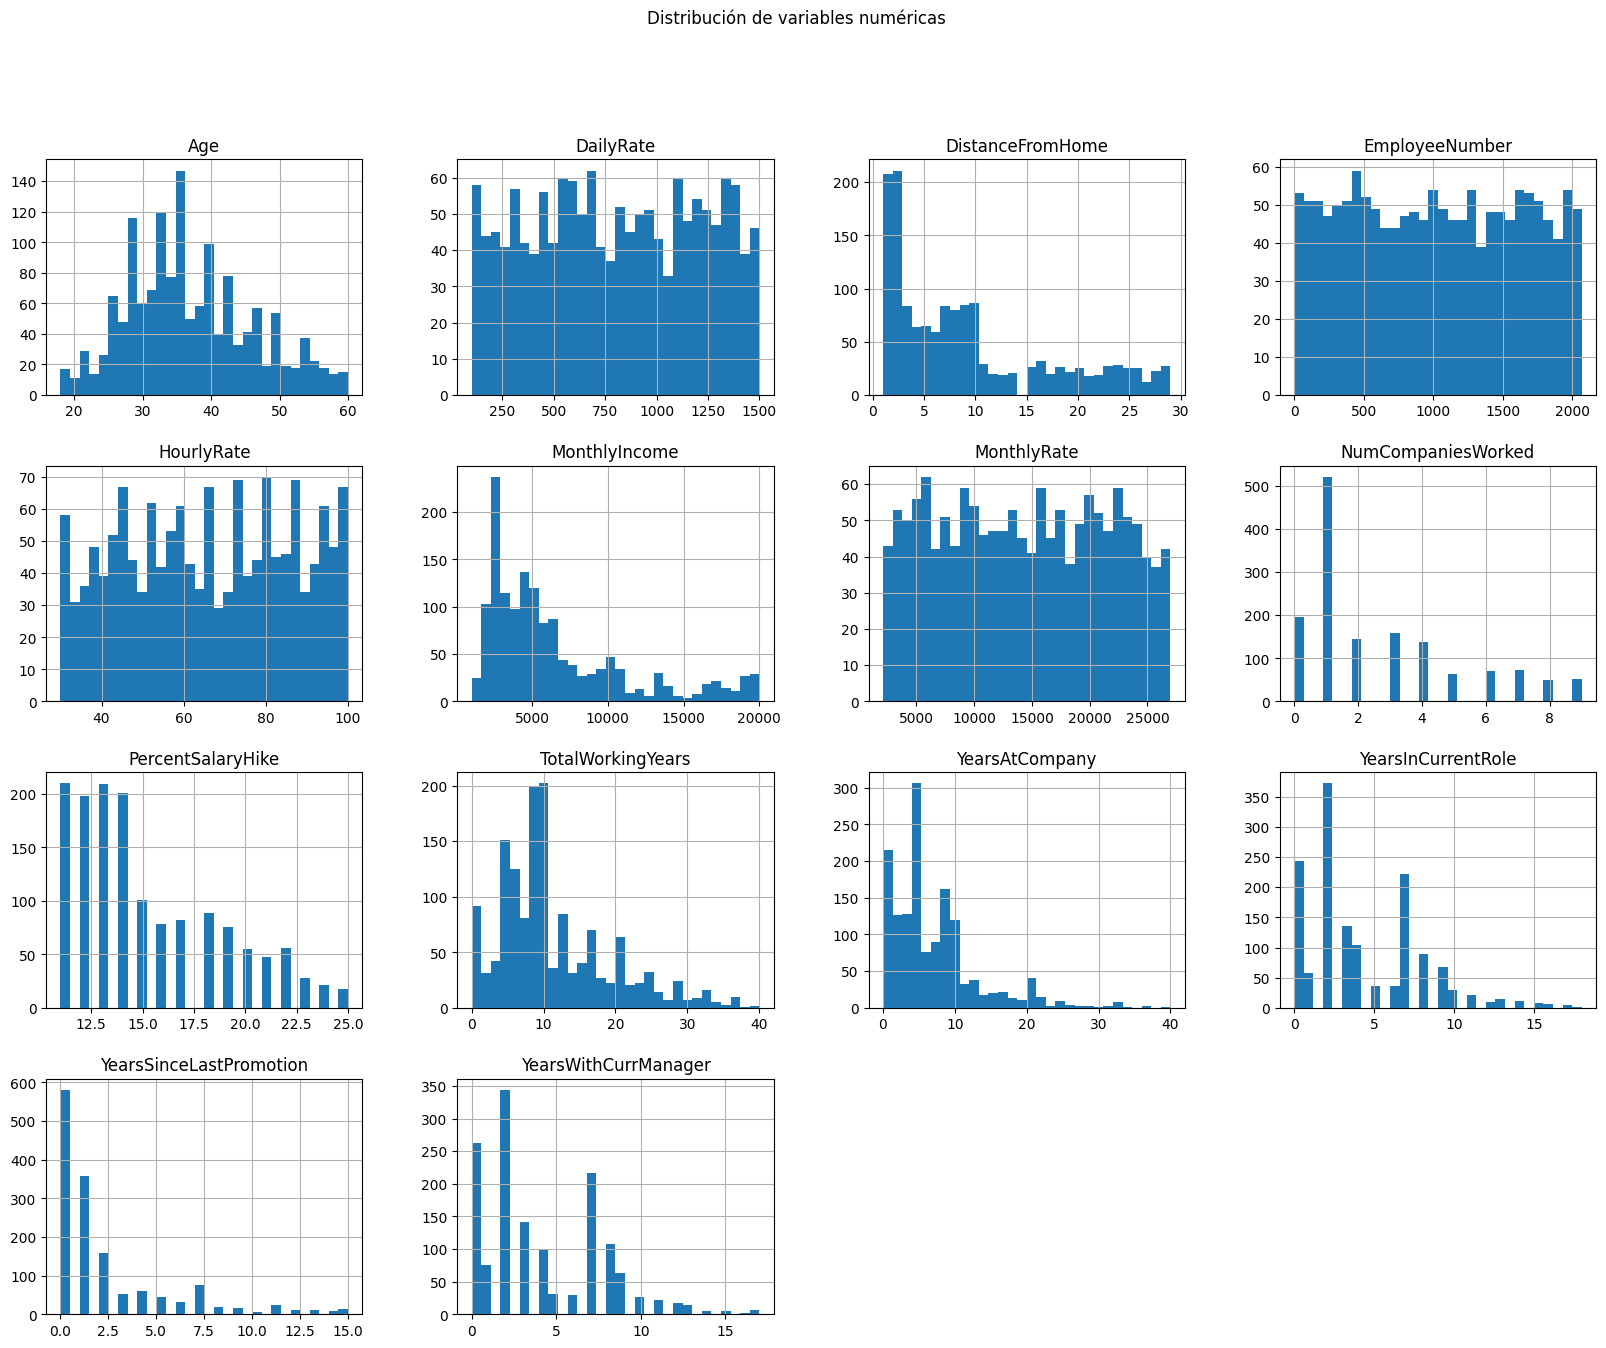

In [ ]:
df[var_hist].hist(bins=30, figsize=(20,15))
plt.suptitle("Distribución de variables numéricas")
plt.show()

***Insights***:
- EmployeeNumber (que es el ID de cada trabajador) y las variables de tipo Rate se parecen a una distribución uniforme. No nos aportan mucho valor

- La Edad, Age, parece una distribución normal con cierta asimetría a derecha

- Otras variables con marcada asimetría a derecha son: YearsSinceLastPromotion (mostrando la dinámica de cambios constantes que usa la empresa), DistanceFromHome y MonthlyIncome (una variable log-normal típicamente).

- Hay otras variables con comportamiento interesante.

Vemos los histogramas uno por uno. Probamos normalidad: ninguna de las distribuciones es normal, según test de Shapiro.

También evaluamos log-normalidad. Algunos valores no son tan confiables porque la cantidad de valores únicos es muy acotada.

Columna: Age
La variable Age no es normal, con p-valor de normalidad de 2.036924313471409e-14
La variable Age no es lognormal, con p-valor de 2.4334192250067207e-08


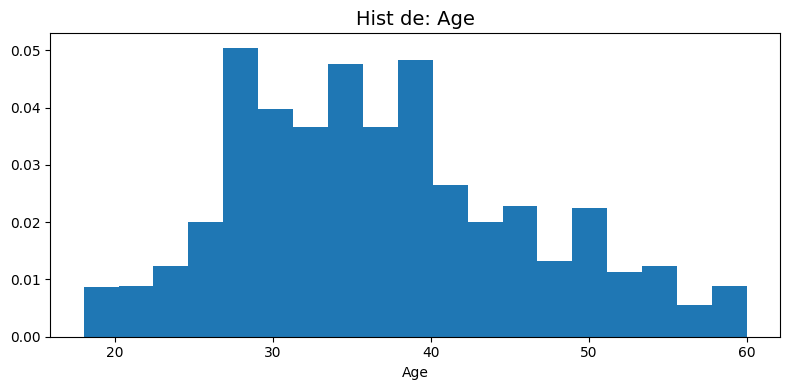

Columna: DailyRate
La variable DailyRate no es normal, con p-valor de normalidad de 5.3293297427466794e-21
La variable DailyRate no es lognormal, con p-valor de 3.222640067929081e-29


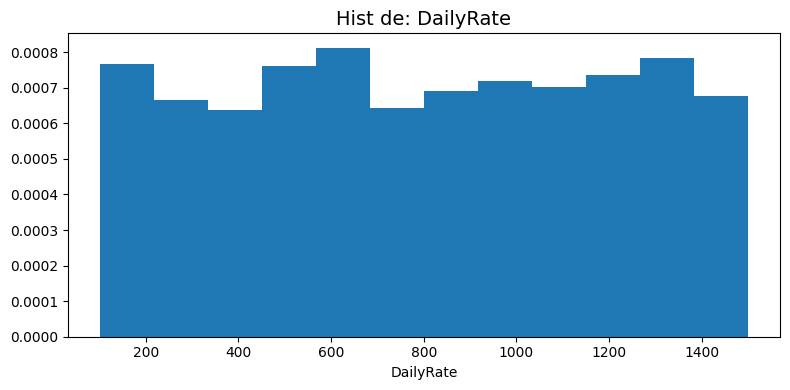

Columna: DistanceFromHome
La variable DistanceFromHome no es normal, con p-valor de normalidad de 4.080847148972798e-34
La variable DistanceFromHome no es lognormal, con p-valor de 1.211303536524709e-25


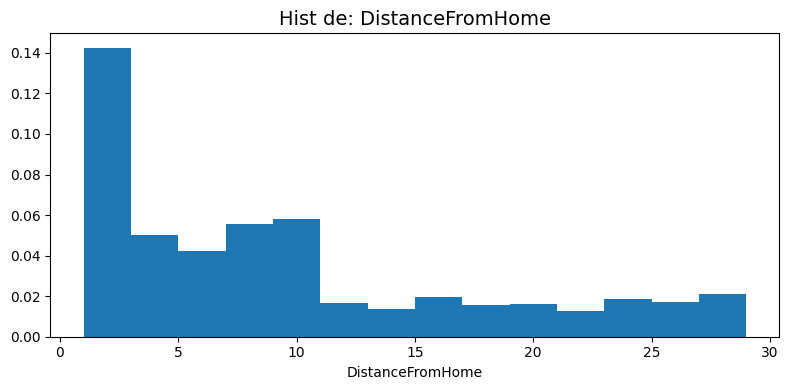

Columna: EmployeeNumber
La variable EmployeeNumber no es normal, con p-valor de normalidad de 2.0013229535054698e-21
La variable EmployeeNumber no es lognormal, con p-valor de 1.5260280847082564e-37


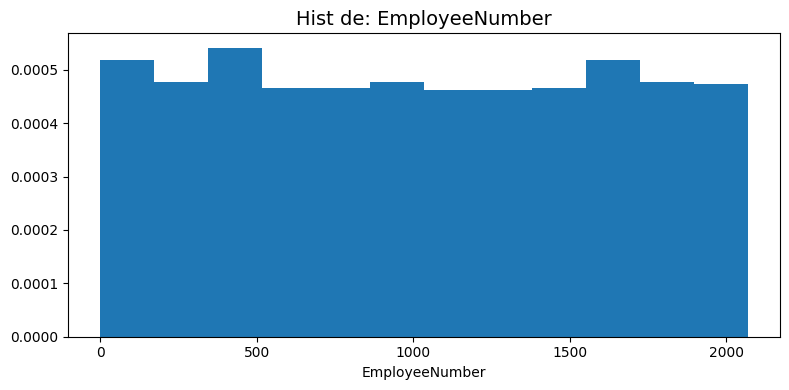

Columna: HourlyRate
La variable HourlyRate no es normal, con p-valor de normalidad de 7.418846333333745e-21
La variable HourlyRate no es lognormal, con p-valor de 1.766381486962182e-23


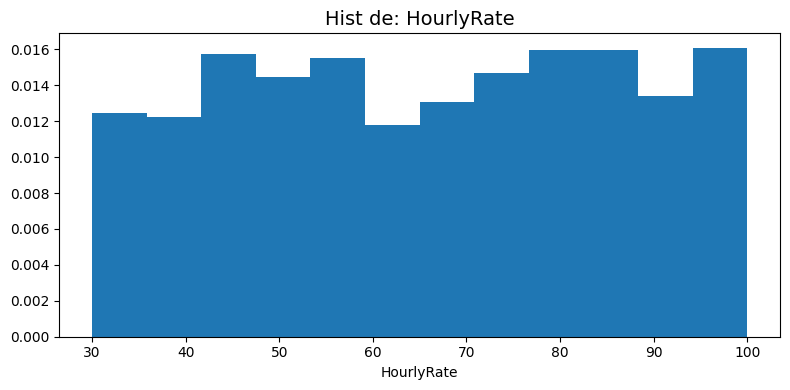

Columna: MonthlyIncome
La variable MonthlyIncome no es normal, con p-valor de normalidad de 4.40239403650134e-37
La variable MonthlyIncome no es lognormal, con p-valor de 5.851852037101201e-17


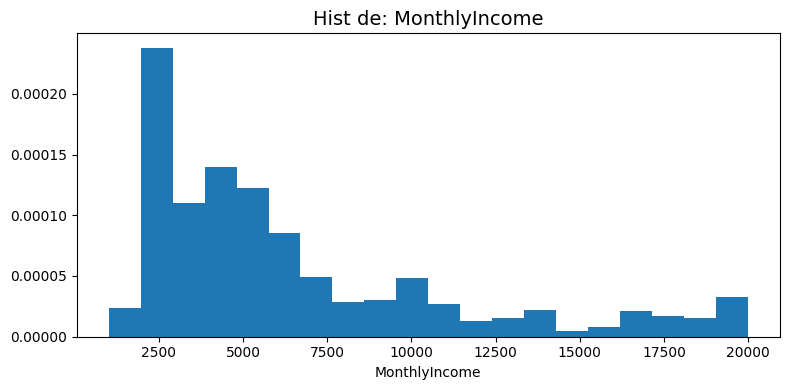

Columna: MonthlyRate
La variable MonthlyRate no es normal, con p-valor de normalidad de 5.5165024117900065e-21
La variable MonthlyRate no es lognormal, con p-valor de 9.01263277039091e-28


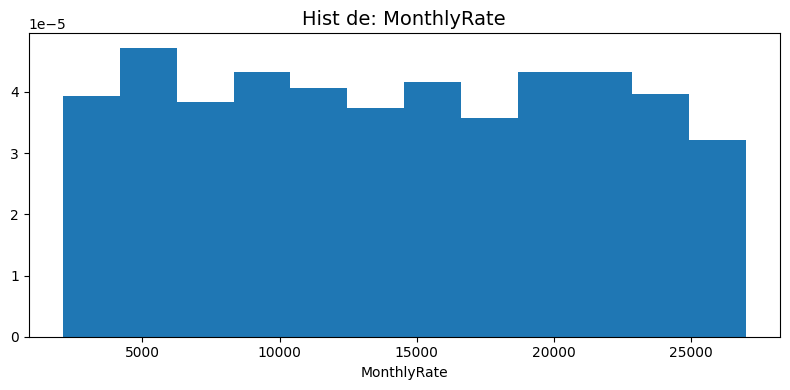

Columna: NumCompaniesWorked
La variable NumCompaniesWorked no es normal, con p-valor de normalidad de 2.6321032253527873e-35
La variable NumCompaniesWorked es lognormal, con p-valor de 1.0


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


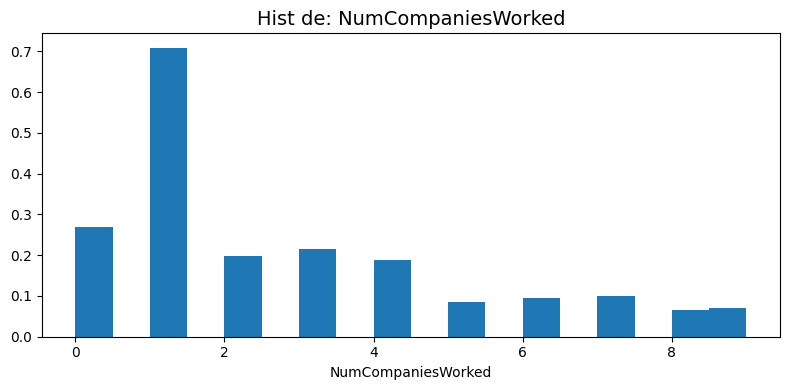

Columna: PercentSalaryHike
La variable PercentSalaryHike no es normal, con p-valor de normalidad de 7.480739720656666e-30
La variable PercentSalaryHike no es lognormal, con p-valor de 1.204512471290401e-25


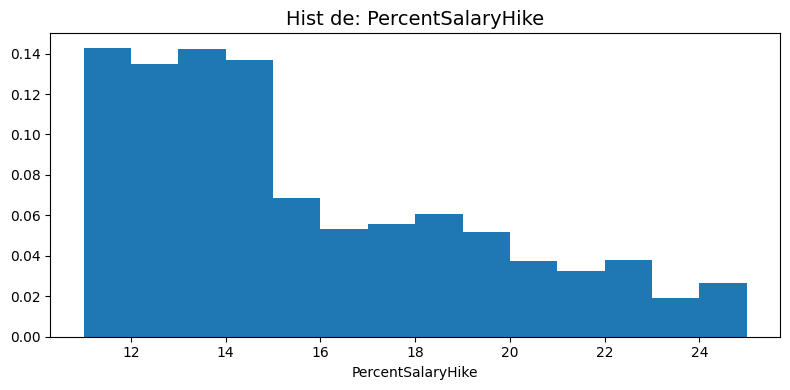

Columna: TotalWorkingYears
La variable TotalWorkingYears no es normal, con p-valor de normalidad de 5.63092214228768e-29
La variable TotalWorkingYears es lognormal, con p-valor de 1.0


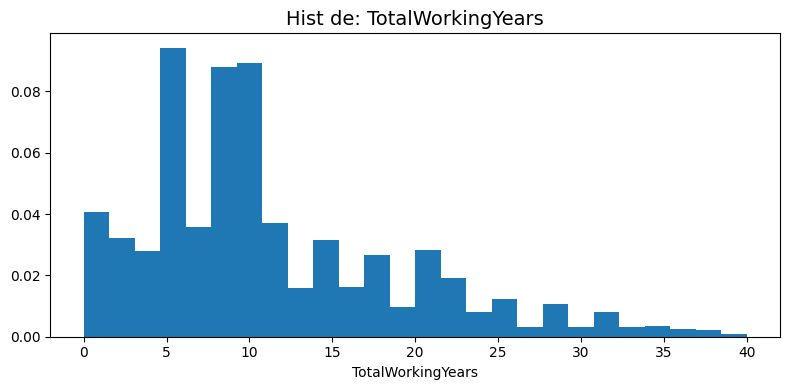

Columna: YearsAtCompany
La variable YearsAtCompany no es normal, con p-valor de normalidad de 3.668867045982291e-36
La variable YearsAtCompany es lognormal, con p-valor de 1.0


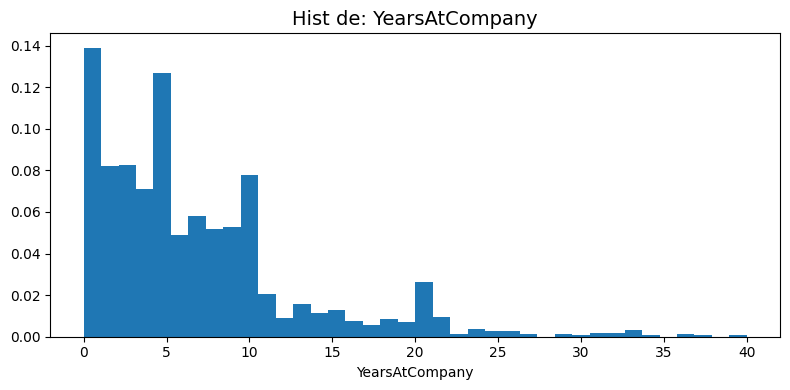

Columna: YearsInCurrentRole
La variable YearsInCurrentRole no es normal, con p-valor de normalidad de 2.142707183927569e-30
La variable YearsInCurrentRole es lognormal, con p-valor de 1.0


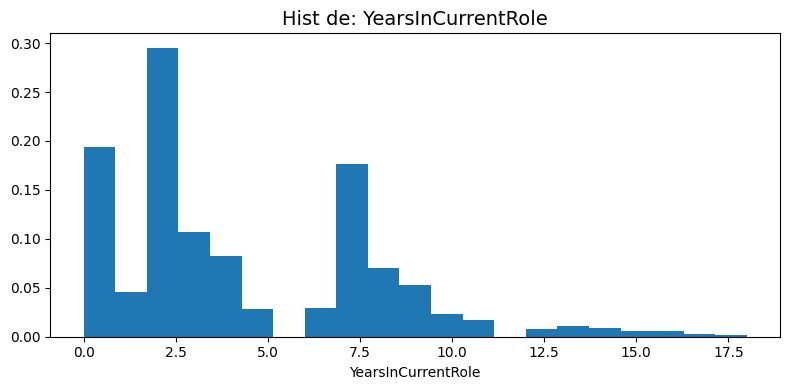

Columna: YearsSinceLastPromotion
La variable YearsSinceLastPromotion no es normal, con p-valor de normalidad de 4.772964882348663e-45
La variable YearsSinceLastPromotion es lognormal, con p-valor de 1.0


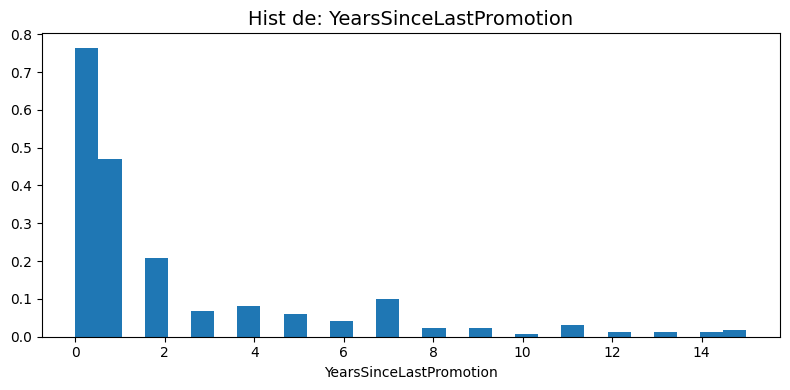

Columna: YearsWithCurrManager
La variable YearsWithCurrManager no es normal, con p-valor de normalidad de 3.055795639575973e-30
La variable YearsWithCurrManager es lognormal, con p-valor de 1.0


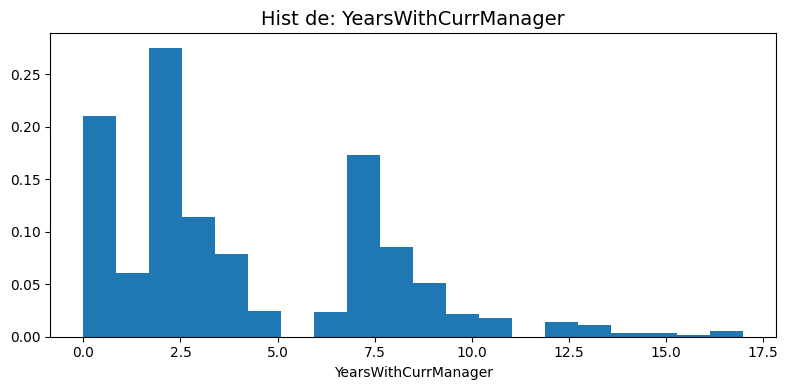

In [ ]:
for col in df[var_hist]:
  test_normalidad = stats.shapiro(df[col])
  print(f'Columna: {col}')
  if test_normalidad.pvalue > 0.05:
    print(f'La variable {col} es normal, con p-valor de normalidad de {test_normalidad.pvalue}')
  else:
    print(f'La variable {col} no es normal, con p-valor de normalidad de {test_normalidad.pvalue}')
  test_lognormalidad = stats.shapiro(np.log(df[col]))
  if test_lognormalidad.pvalue > 0.05:
    print(f'La variable {col} es lognormal, con p-valor de {test_lognormalidad.pvalue}')
  else:
    print(f'La variable {col} no es lognormal, con p-valor de {test_lognormalidad.pvalue}')
  plt.figure(figsize=(8, 4))
  plt.hist(df[col], bins='auto', density=True)
  plt.title(f"Hist de: {col}", fontsize=14)
  plt.xlabel(col)
  plt.tight_layout()
  plt.show()

Graficamos las otras variables. Ahora con un gráfico de barras.

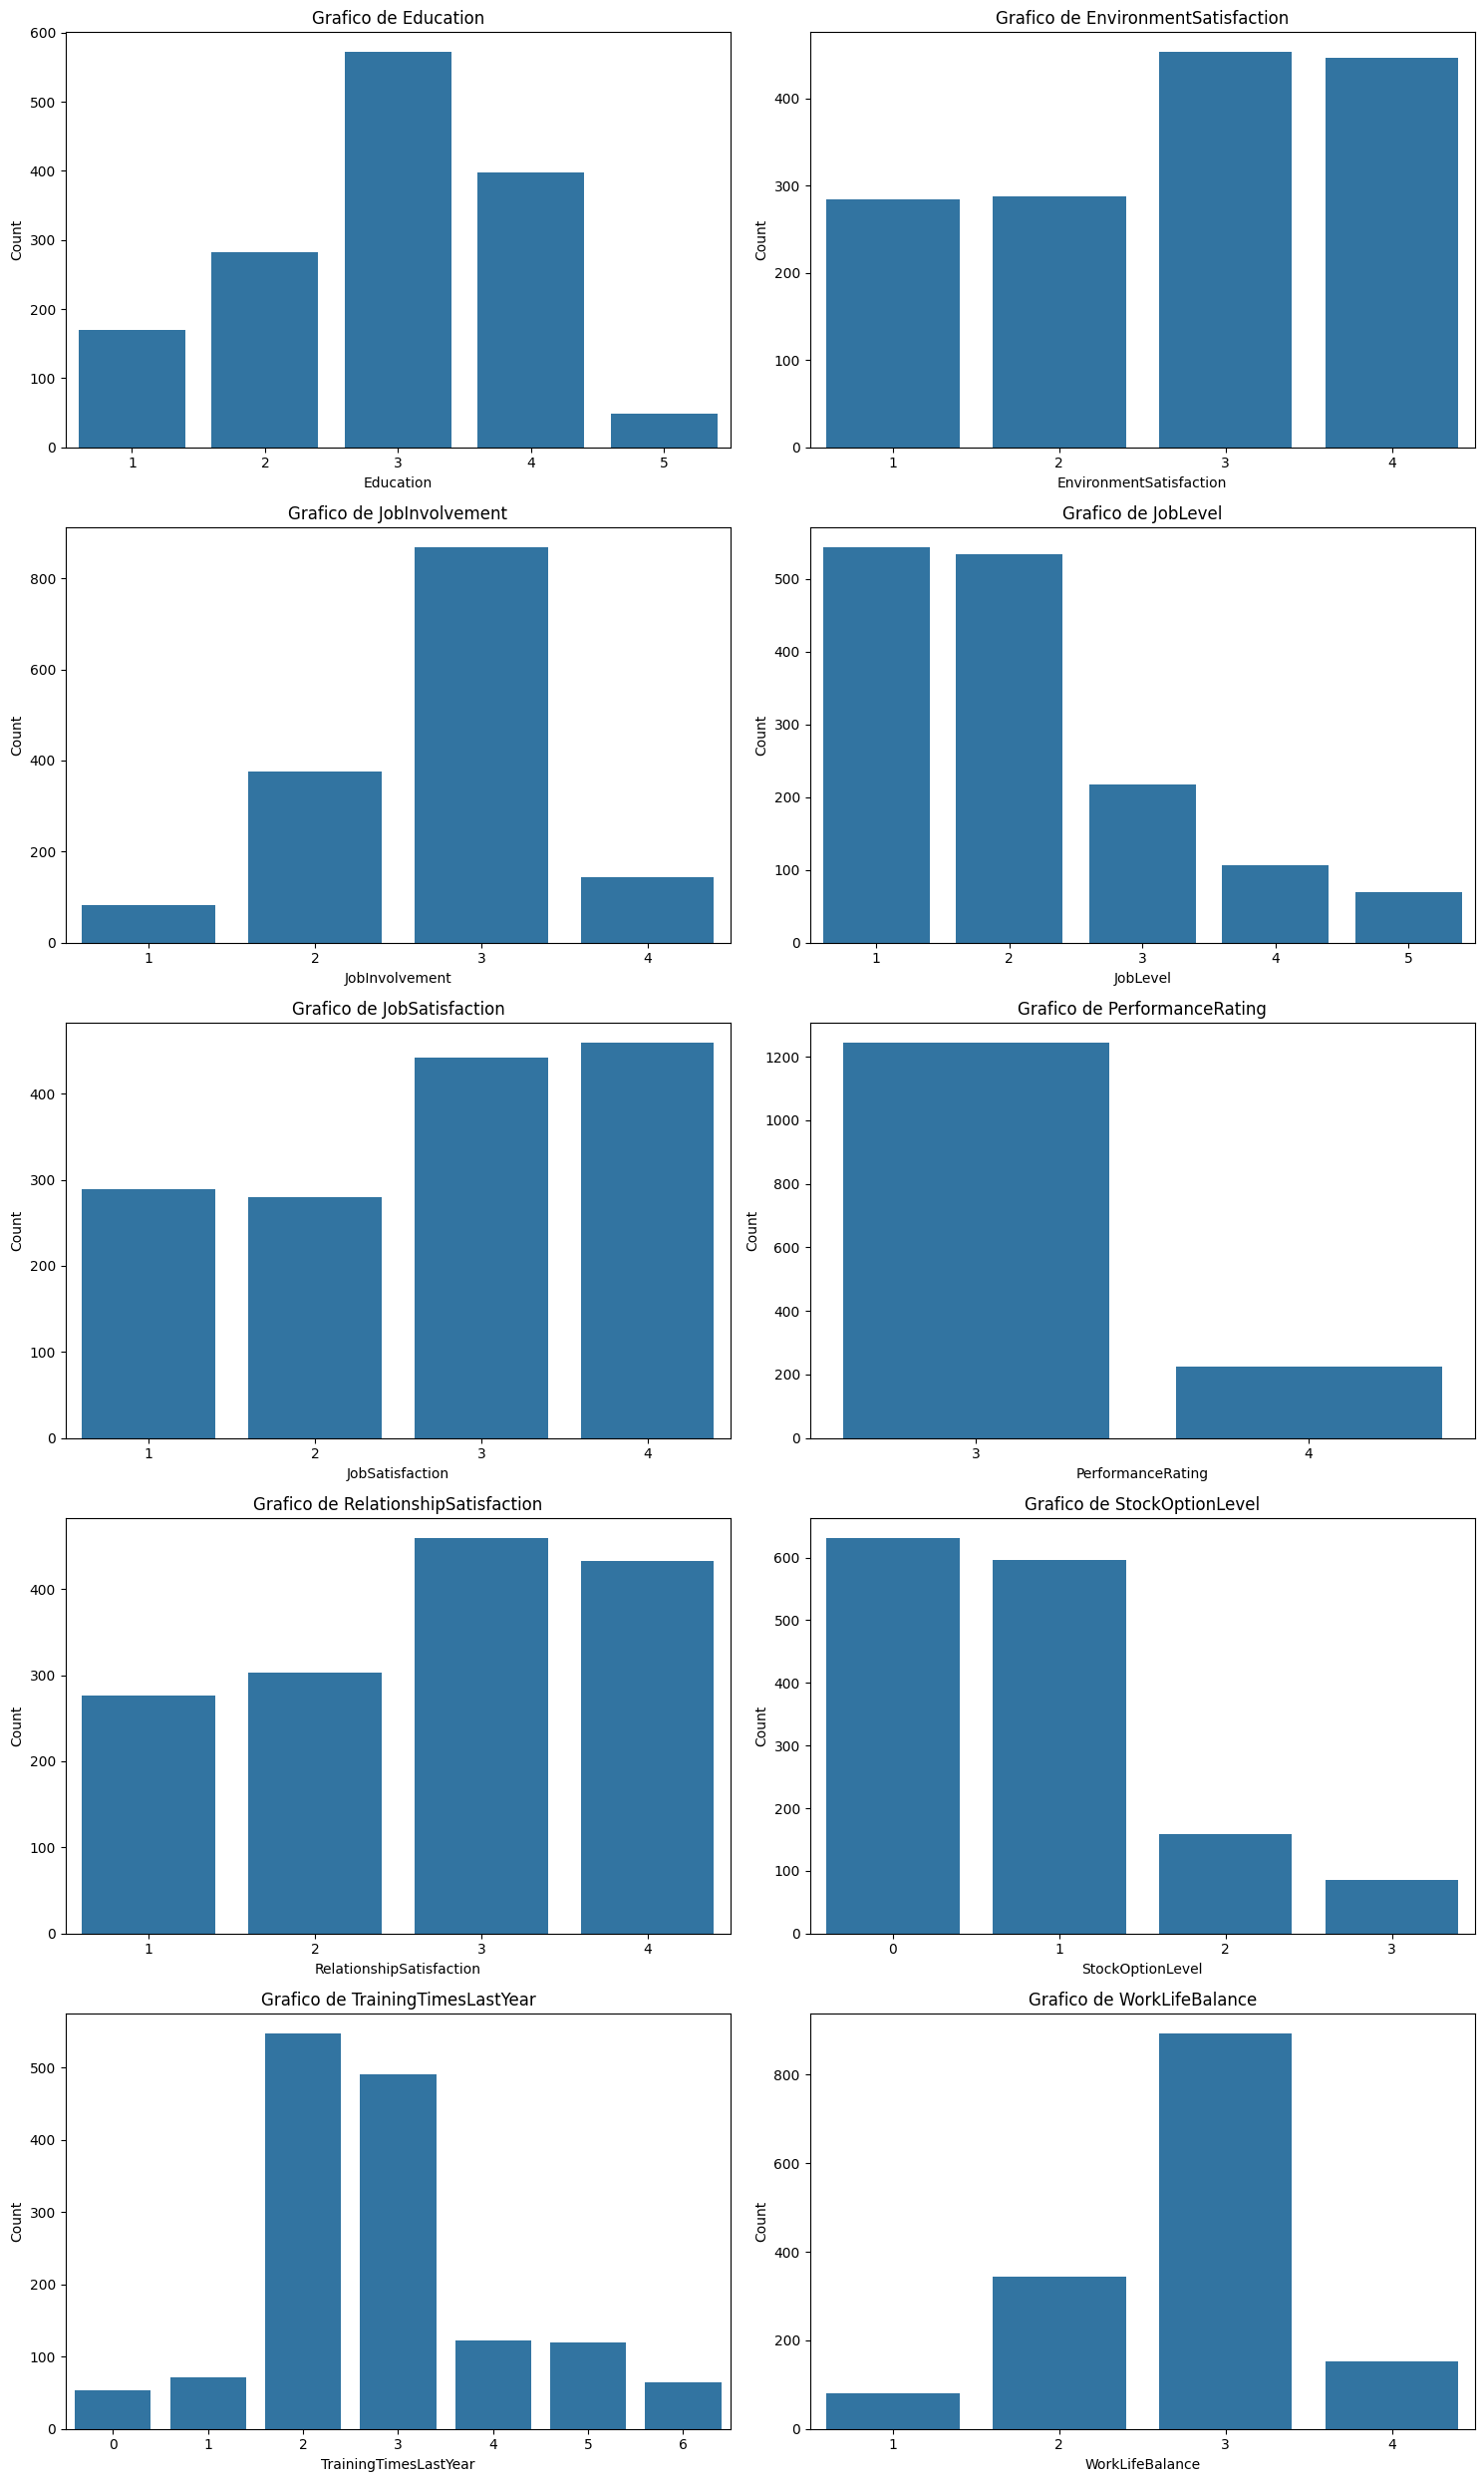

In [ ]:
import math

var_bar = [i for i in df.select_dtypes(include='number').columns if i not in var_hist]

# Calculate the number of rows needed for 2 plots per row
n_cols = 2
n_rows = math.ceil(len(var_bar) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(var_bar):
  sns.countplot(data=df, x=col, ax=axes[i])
  axes[i].set_title(f'Grafico de {col}')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Count')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

***Insights***:

- La mayoría de los trabajadores tienen un grado de educación interedio
- Hay una mitad de los trabajadores con un grado de satisfacción en los distintos aspectos del trabajo en sí, mayor al de la otra mitad
- La gran mayoría tiene compromiso con su trabajo, pero no le dan el 100%
- Como puede esperarse, hay más gente en trabajos de menor rango que en trabajos más gerenciales
- El PerformanceRating tiene solo 2 valores. Se necesita analizar esa como investigador para determinar si se trata de un error en la carga de datos
- Son pocos los que pueden acceder a acciones de la empresa

Vemos las distribuciones ahora con un boxplot. Hacemos esto solo para columnas de más de 10 valores únicos.

Columna Age de 43 valores


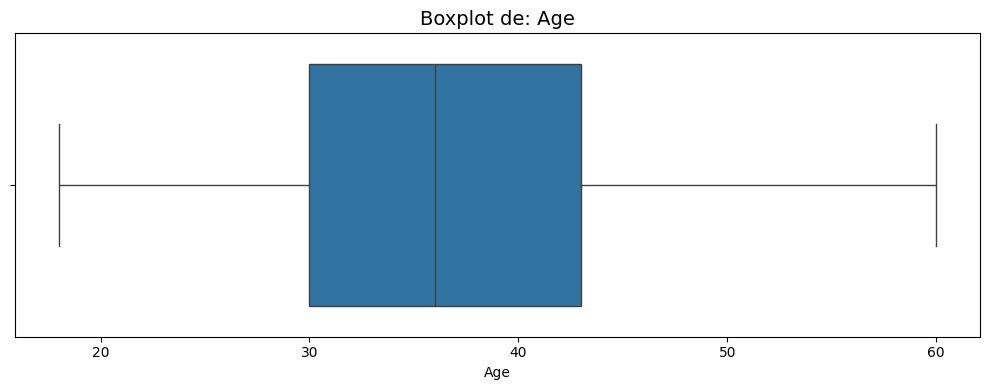

Columna DailyRate de 886 valores


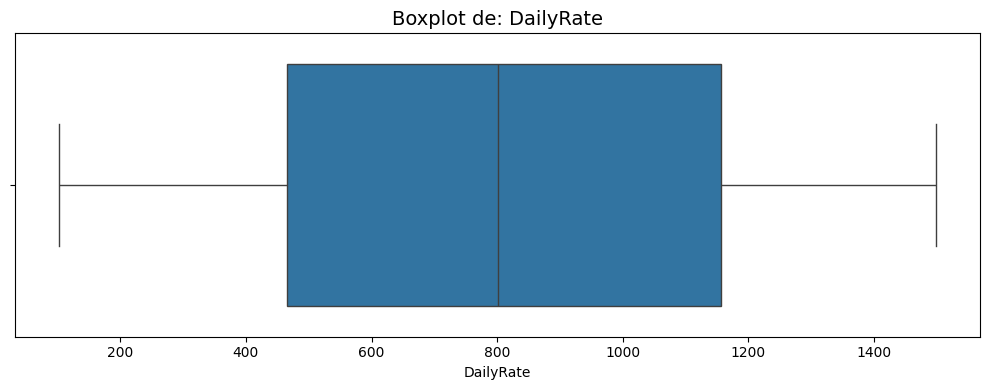

Columna DistanceFromHome de 29 valores


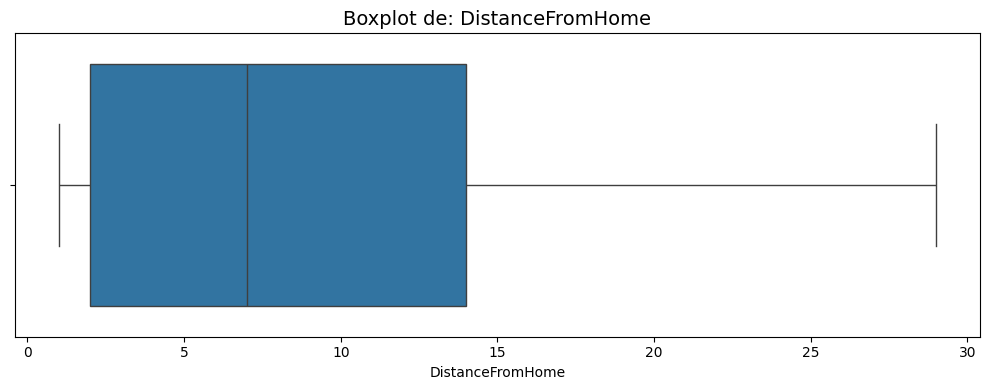

Columna Education de 5 valores
Columna EmployeeNumber de 1470 valores


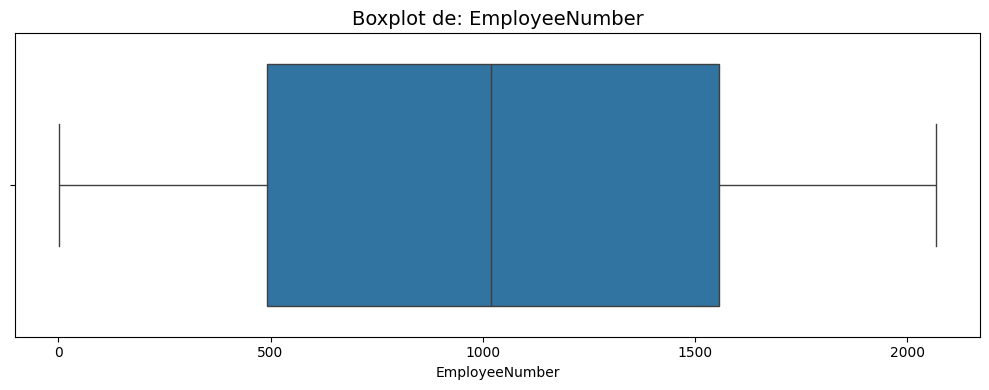

Columna EnvironmentSatisfaction de 4 valores
Columna HourlyRate de 71 valores


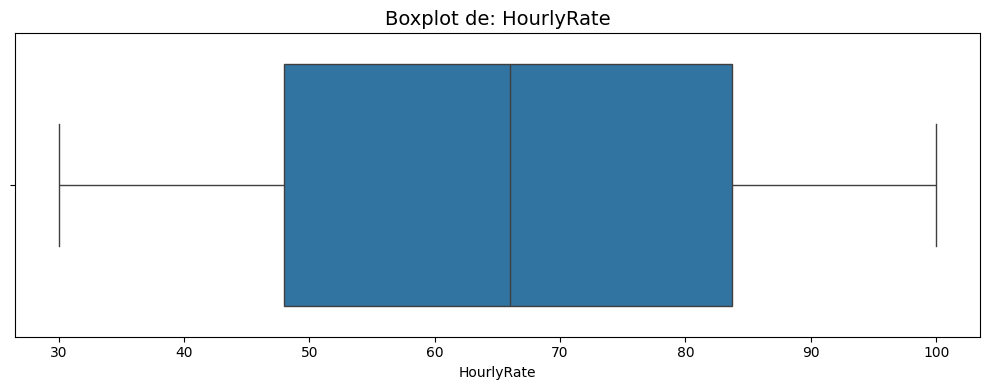

Columna JobInvolvement de 4 valores
Columna JobLevel de 5 valores
Columna JobSatisfaction de 4 valores
Columna MonthlyIncome de 1349 valores


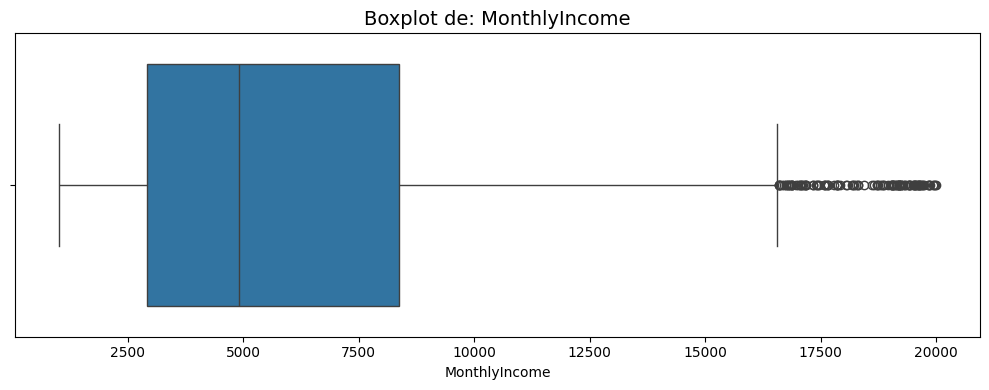

Columna MonthlyRate de 1427 valores


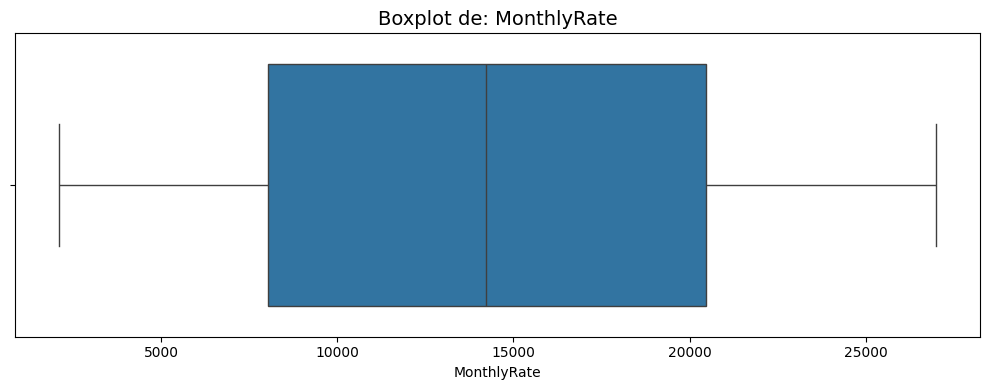

Columna NumCompaniesWorked de 10 valores


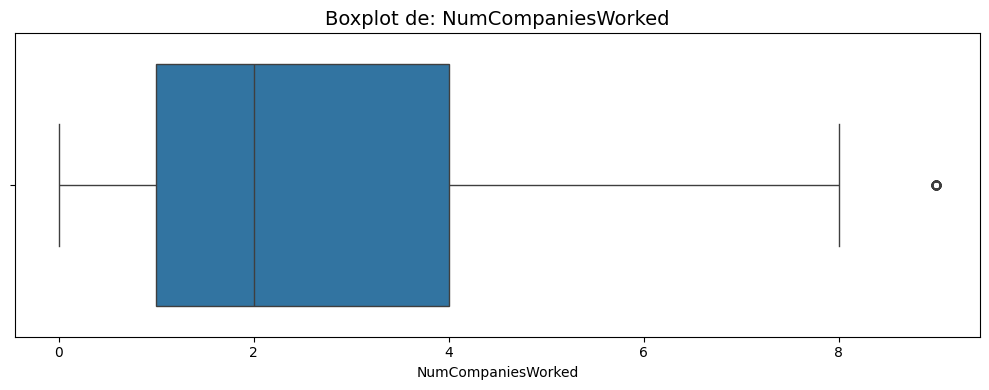

Columna PercentSalaryHike de 15 valores


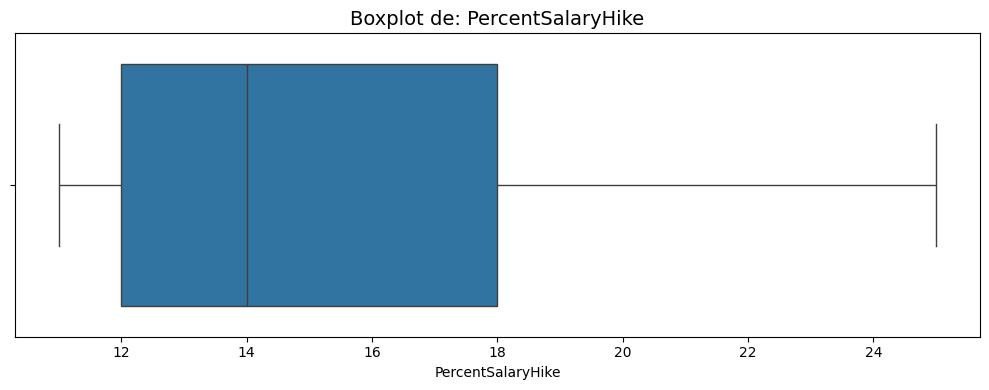

Columna PerformanceRating de 2 valores
Columna RelationshipSatisfaction de 4 valores
Columna StockOptionLevel de 4 valores
Columna TotalWorkingYears de 40 valores


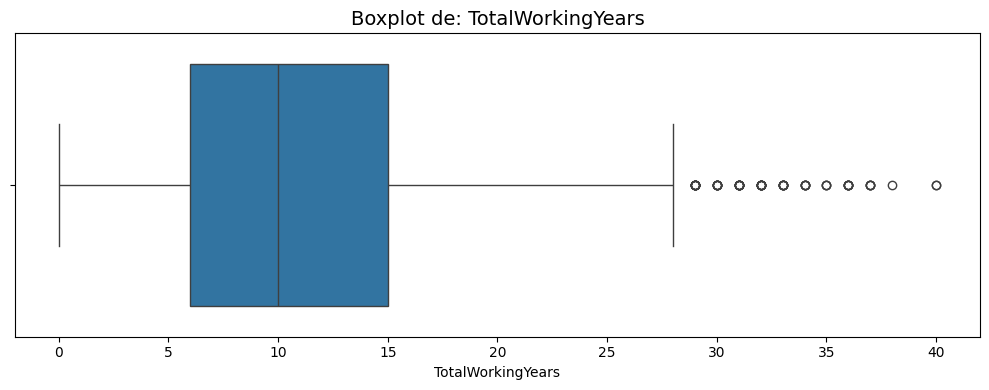

Columna TrainingTimesLastYear de 7 valores
Columna WorkLifeBalance de 4 valores
Columna YearsAtCompany de 37 valores


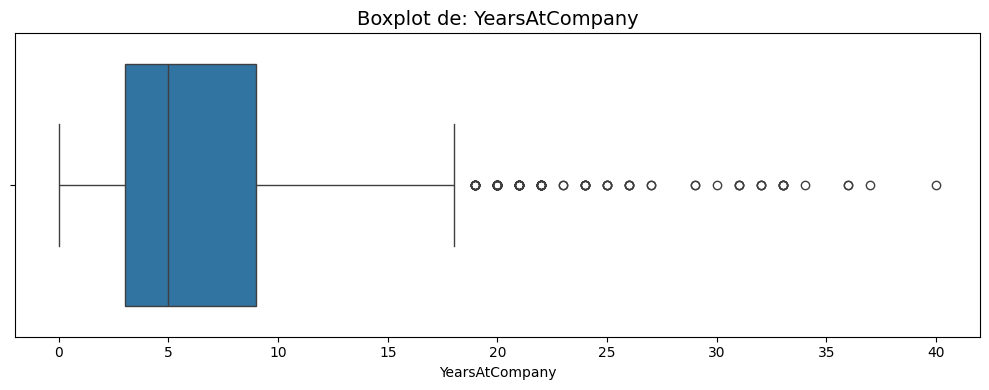

Columna YearsInCurrentRole de 19 valores


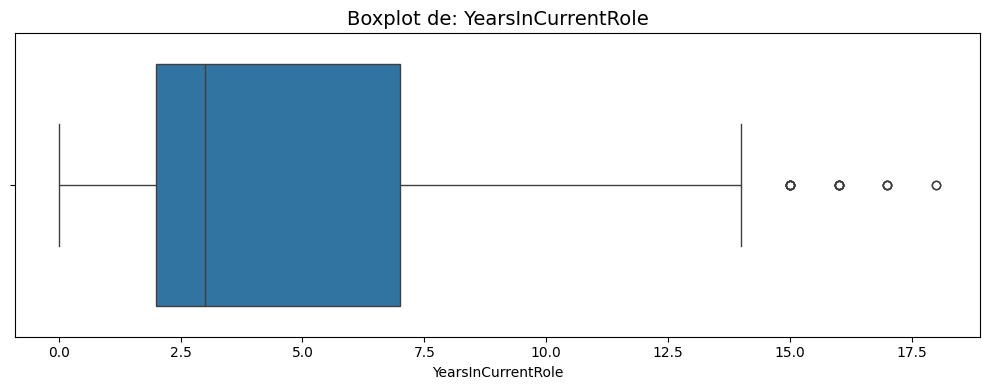

Columna YearsSinceLastPromotion de 16 valores


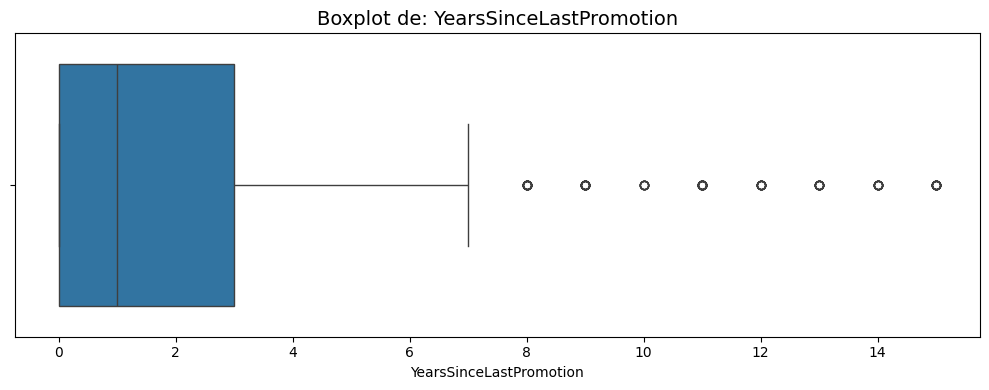

Columna YearsWithCurrManager de 18 valores


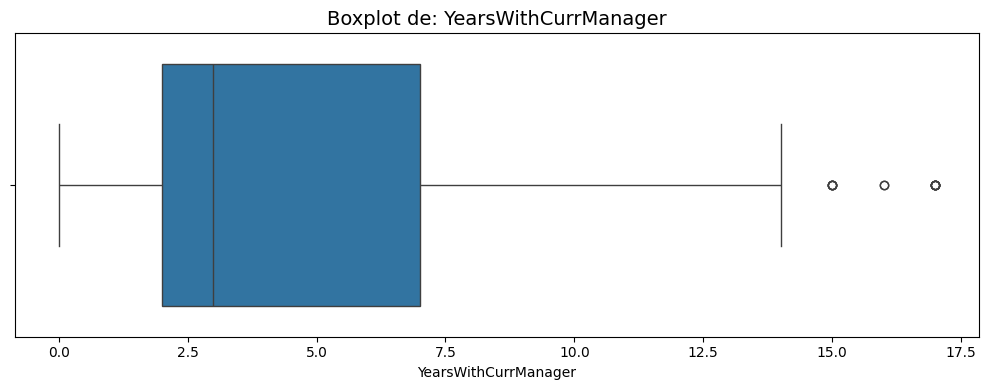

In [ ]:
var_boxplot = []
for col in df.select_dtypes(include='number'):
  cantidad = df[col].nunique()
  print(f'Columna {col} de {cantidad} valores')
  if cantidad >= 10:
    var_boxplot.append(col)
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot de: {col}", fontsize=14)
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [ ]:
def detectar_outliers_iqr(df, columna, severos = False):
    if severos == True:
      sep = 3
    else:
      sep = 1.5
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - sep * IQR
    limite_superior = Q3 + sep * IQR
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    return outliers.index

df_outliers_severos = pd.DataFrame()
qOutliers = 0
qOutliersSeveros = 0
for col in var_boxplot:
    outliers = detectar_outliers_iqr(df, col)
    outliers_severos = detectar_outliers_iqr(df, col, severos=True)
    print(f"{col} (nunique: {df[col].nunique()}): {len(outliers)} outliers totales ({len(outliers) / len(df) * 100:.2f}%)",
          f" y {len(outliers_severos)} outliers severos ({len(outliers_severos) / len(df) * 100:.2f}%)",sep='', end='\n')
    qOutliers+= len(outliers)
    qOutliersSeveros+= len(outliers_severos)
    outliers_severos = pd.Series(outliers_severos.tolist())
    df_outliers_severos = pd.concat([df_outliers_severos,outliers_severos])

print(f'En total hay {qOutliers} outliers y {qOutliersSeveros} outliers severos')

Age (nunique: 43): 0 outliers totales (0.00%) y 0 outliers severos (0.00%)
DailyRate (nunique: 886): 0 outliers totales (0.00%) y 0 outliers severos (0.00%)
DistanceFromHome (nunique: 29): 0 outliers totales (0.00%) y 0 outliers severos (0.00%)
EmployeeNumber (nunique: 1470): 0 outliers totales (0.00%) y 0 outliers severos (0.00%)
HourlyRate (nunique: 71): 0 outliers totales (0.00%) y 0 outliers severos (0.00%)
MonthlyIncome (nunique: 1349): 114 outliers totales (7.76%) y 0 outliers severos (0.00%)
MonthlyRate (nunique: 1427): 0 outliers totales (0.00%) y 0 outliers severos (0.00%)
NumCompaniesWorked (nunique: 10): 52 outliers totales (3.54%) y 0 outliers severos (0.00%)
PercentSalaryHike (nunique: 15): 0 outliers totales (0.00%) y 0 outliers severos (0.00%)
TotalWorkingYears (nunique: 40): 63 outliers totales (4.29%) y 0 outliers severos (0.00%)
YearsAtCompany (nunique: 37): 104 outliers totales (7.07%) y 19 outliers severos (1.29%)
YearsInCurrentRole (nunique: 19): 21 outliers totale

### **2.2 Outliers**

Variables con Outliers: la mayoria son de variables de cantida de años, donde hay personas que trabajan hace mucho entonces se despegan del comun de los trabajadores

- MonthlyIncome: 114 outliers (ninguno severo). Decidimos dejar los outliers ya que creemos que tiene sentido que la variable de ingreso mensual contenga valores atípicos. Además, representa solo el 7,76% de las observaciones.

- NumCompaniesWorked: 52 outliers, pero tienen sentido

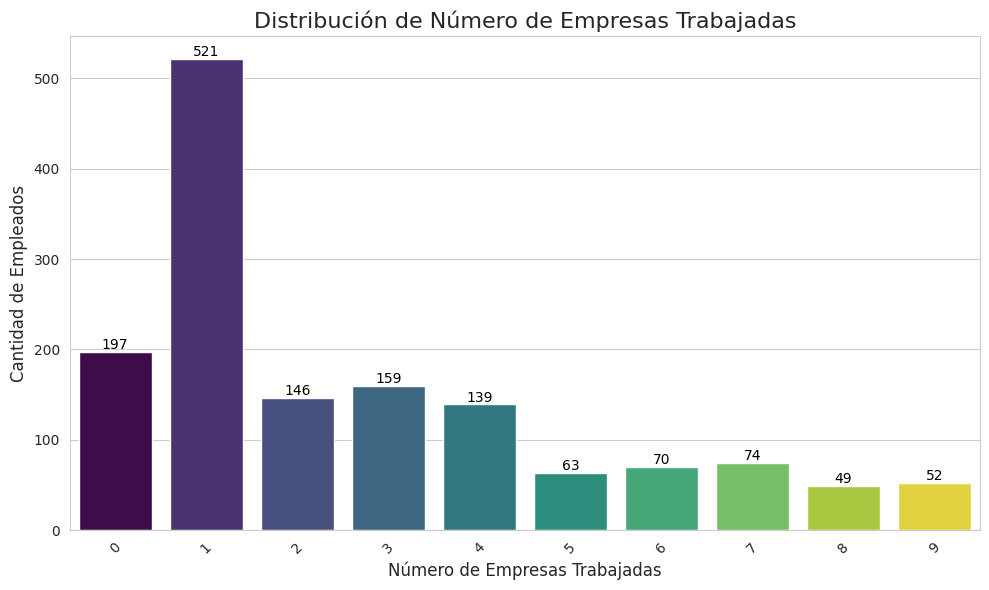

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')
ax = sns.countplot(data=df, x='NumCompaniesWorked', hue='NumCompaniesWorked', palette='viridis', legend=False)
plt.title('Distribución de Número de Empresas Trabajadas', fontsize=16)
plt.xlabel('Número de Empresas Trabajadas', fontsize=12)
plt.ylabel('Cantidad de Empleados', fontsize=12)

# Añadir anotaciones de cantidad en cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- TotalWorkingYears: 63 outliers. No son un error

- YearsAtCompany: 104 outliers, de los cuales 19 son severos

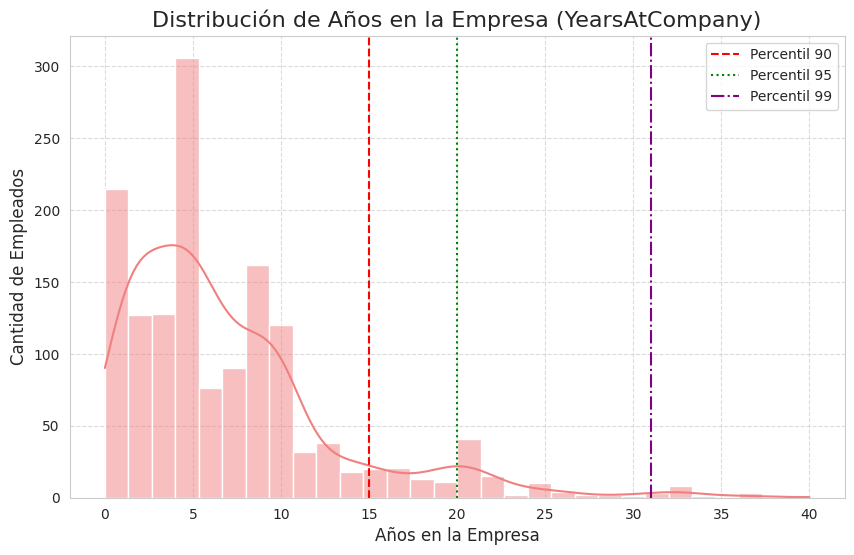

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['YearsAtCompany'], bins=30, kde=True, color='lightcoral')
plt.title('Distribución de Años en la Empresa (YearsAtCompany)', fontsize=16)
plt.xlabel('Años en la Empresa', fontsize=12)
plt.ylabel('Cantidad de Empleados', fontsize=12)
plt.axvline(df['YearsAtCompany'].quantile(0.90), color='red', linestyle='--', label='Percentil 90')
plt.axvline(df['YearsAtCompany'].quantile(0.95), color='green', linestyle=':', label='Percentil 95')
plt.axvline(df['YearsAtCompany'].quantile(0.99), color='purple', linestyle='-.', label='Percentil 99')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Decidimos aplicar la técnica de Windsoring, estableciendo el percentil 95 como límite superior.

In [ ]:
percentil_95_years_at_company = df['YearsAtCompany'].quantile(0.95)
df['YearsAtCompany_Winsorized'] = df['YearsAtCompany'].clip(upper=percentil_95_years_at_company)

print(f"Valor del percentil 95 para YearsAtCompany: {percentil_95_years_at_company:.2f}")

# Verificar los cambios mostrando algunas filas donde se aplicó la winsorización
display(df[['YearsAtCompany', 'YearsAtCompany_Winsorized']].sort_values(by='YearsAtCompany', ascending=False).head(10))

Valor del percentil 95 para YearsAtCompany: 20.00


,YearsAtCompany,YearsAtCompany_Winsorized
126,40,20
98,37,20
1116,36,20
270,36,20
561,34,20
914,33,20
1111,33,20
962,33,20
237,33,20
190,33,20


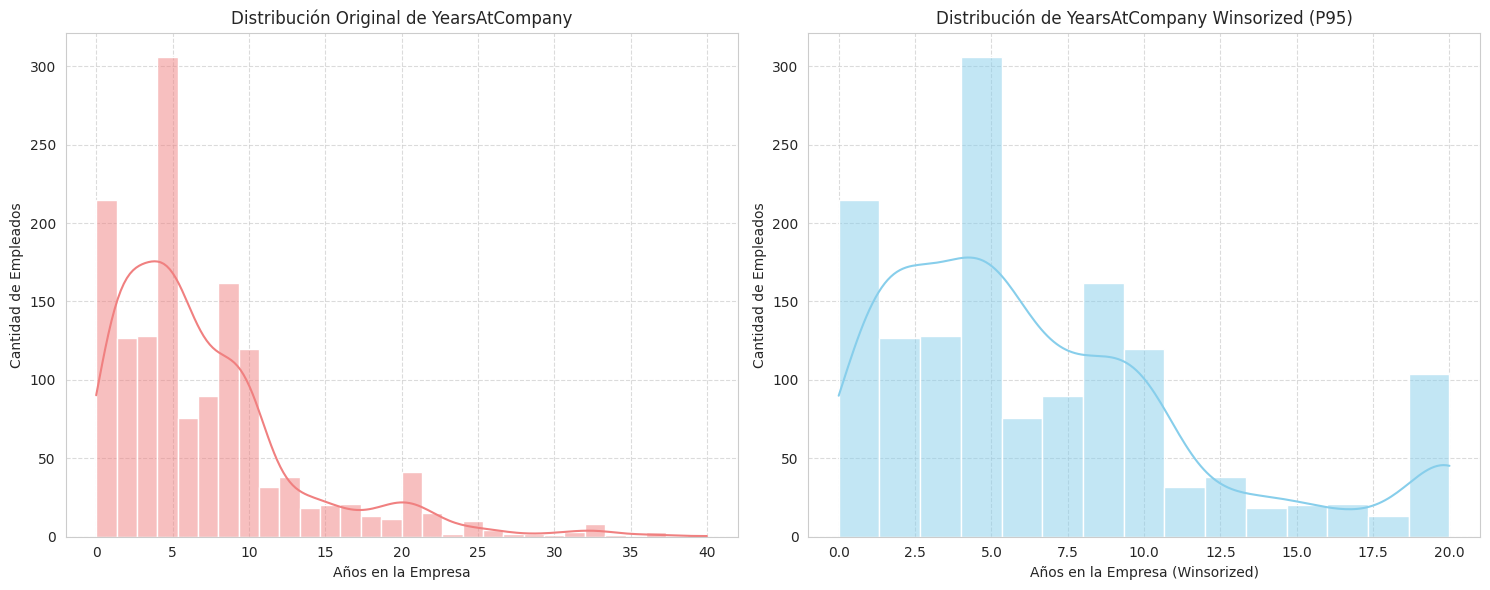

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['YearsAtCompany'], bins=30, kde=True, color='lightcoral')
plt.title('Distribución Original de YearsAtCompany')
plt.xlabel('Años en la Empresa')
plt.ylabel('Cantidad de Empleados')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
sns.histplot(df['YearsAtCompany_Winsorized'], bins=15, kde=True, color='skyblue')
plt.title('Distribución de YearsAtCompany Winsorized (P95)')
plt.xlabel('Años en la Empresa (Winsorized)')
plt.ylabel('Cantidad de Empleados')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Podemos ver que la forma de la distribución se mantiene después de aplicar la técnica.

In [ ]:
df.drop(columns=['YearsAtCompany'], inplace=True)

Eliminamos la columna original y dejamos únicamente la transformada sin outliers.

- YearsInCurrentRole: 21 outliers

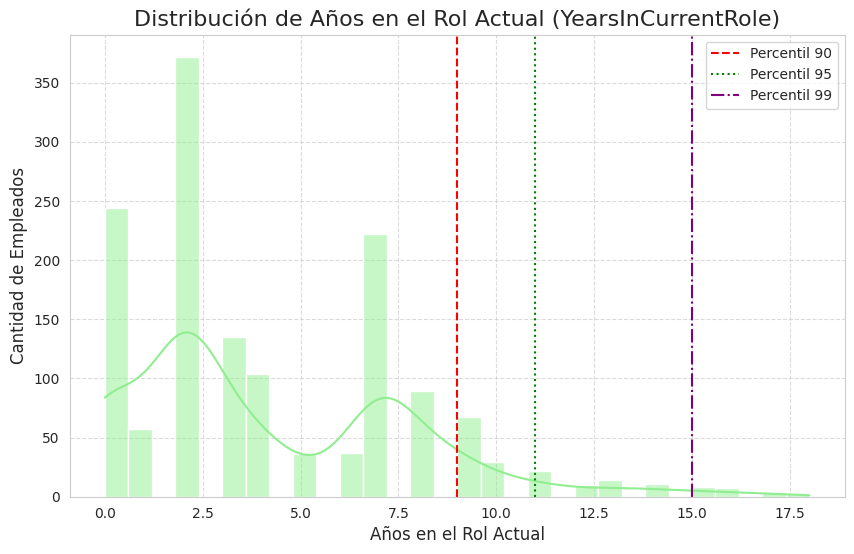

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['YearsInCurrentRole'], bins=30, kde=True, color='lightgreen')
plt.title('Distribución de Años en el Rol Actual (YearsInCurrentRole)', fontsize=16)
plt.xlabel('Años en el Rol Actual', fontsize=12)
plt.ylabel('Cantidad de Empleados', fontsize=12)
plt.axvline(df['YearsInCurrentRole'].quantile(0.90), color='red', linestyle='--', label='Percentil 90')
plt.axvline(df['YearsInCurrentRole'].quantile(0.95), color='green', linestyle=':', label='Percentil 95')
plt.axvline(df['YearsInCurrentRole'].quantile(0.99), color='purple', linestyle='-.', label='Percentil 99')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Decidimos aplicar la técnica de Windsoring, estableciendo el percentil 95 como límite superior.

Valor del percentil 95 para YearsInCurrentRole: 11.00


,YearsInCurrentRole,YearsInCurrentRole_Winsorized
190,18,11
123,18,11
1024,17,11
1327,17,11
231,17,11
1351,17,11
746,16,11
976,16,11
716,16,11
466,16,11


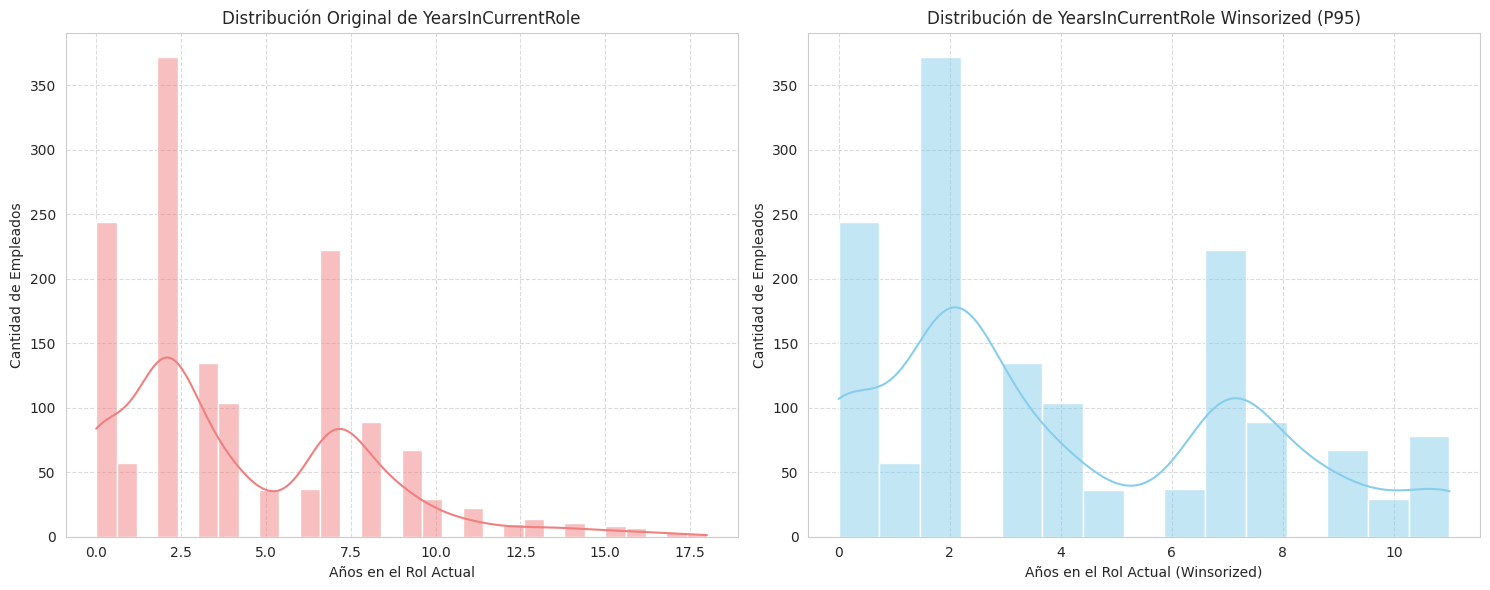

In [ ]:
percentil_95_years_in_current_role = df['YearsInCurrentRole'].quantile(0.95)
df['YearsInCurrentRole_Winsorized'] = df['YearsInCurrentRole'].clip(upper=percentil_95_years_in_current_role)

print(f"Valor del percentil 95 para YearsInCurrentRole: {percentil_95_years_in_current_role:.2f}")

# Verificar los cambios mostrando algunas filas donde se aplicó la winsorización
display(df[['YearsInCurrentRole', 'YearsInCurrentRole_Winsorized']].sort_values(by='YearsInCurrentRole', ascending=False).head(10))

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['YearsInCurrentRole'], bins=30, kde=True, color='lightcoral')
plt.title('Distribución Original de YearsInCurrentRole')
plt.xlabel('Años en el Rol Actual')
plt.ylabel('Cantidad de Empleados')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
sns.histplot(df['YearsInCurrentRole_Winsorized'], bins=15, kde=True, color='skyblue')
plt.title('Distribución de YearsInCurrentRole Winsorized (P95)')
plt.xlabel('Años en el Rol Actual (Winsorized)')
plt.ylabel('Cantidad de Empleados')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
df.drop(columns=['YearsInCurrentRole'], inplace=True)

Eliminamos la columna original y dejamos únicamente la trasnformada sin outliers.

- YearsSinceLastPromotion: 107 outliers, con 32 siendo severos

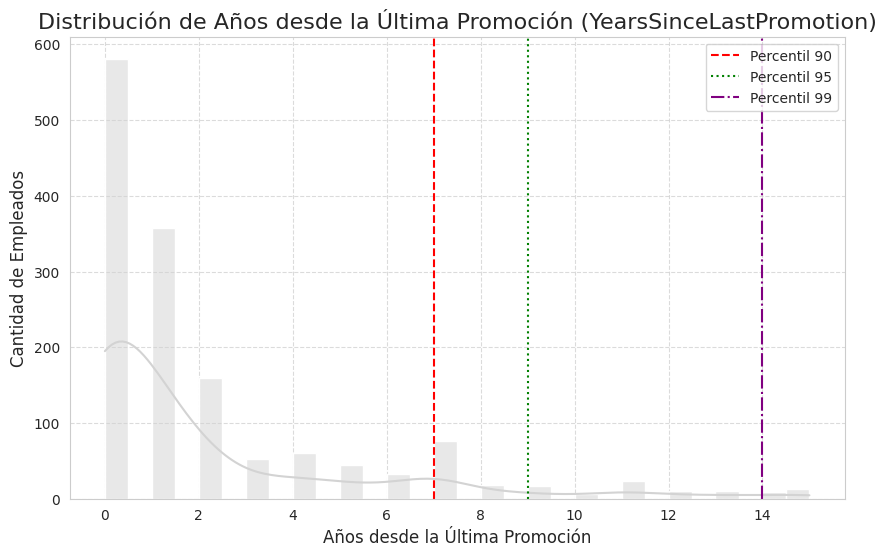

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['YearsSinceLastPromotion'], bins=30, kde=True, color='lightgray')
plt.title('Distribución de Años desde la Última Promoción (YearsSinceLastPromotion)', fontsize=16)
plt.xlabel('Años desde la Última Promoción', fontsize=12)
plt.ylabel('Cantidad de Empleados', fontsize=12)
plt.axvline(df['YearsSinceLastPromotion'].quantile(0.90), color='red', linestyle='--', label='Percentil 90')
plt.axvline(df['YearsSinceLastPromotion'].quantile(0.95), color='green', linestyle=':', label='Percentil 95')
plt.axvline(df['YearsSinceLastPromotion'].quantile(0.99), color='purple', linestyle='-.', label='Percentil 99')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print(df['YearsSinceLastPromotion'].value_counts().sort_index())

YearsSinceLastPromotion
0     581
1     357
2     159
3      52
4      61
5      45
6      32
7      76
8      18
9      17
10      6
11     24
12     10
13     10
14      9
15     13
Name: count, dtype: int64


Decidimos aplicar la técnica de Windsoring, estableciendo el valor de 8 años desde la última promoción como límite superior. Tomamos este valor ya que, al ver el conteo de frecuencias, nos pareció un valor lógico para que la frecuencia del límite superior no sea demasiado alta con respecto a las barras anteriores.

Valor del corte superior para YearsSinceLastPromotion: 8


,YearsSinceLastPromotion,YearsSinceLastPromotion_Winsorized_Fixed
123,15,8
976,15,8
861,15,8
45,15,8
237,15,8
937,15,8
926,15,8
914,15,8
701,15,8
178,15,8


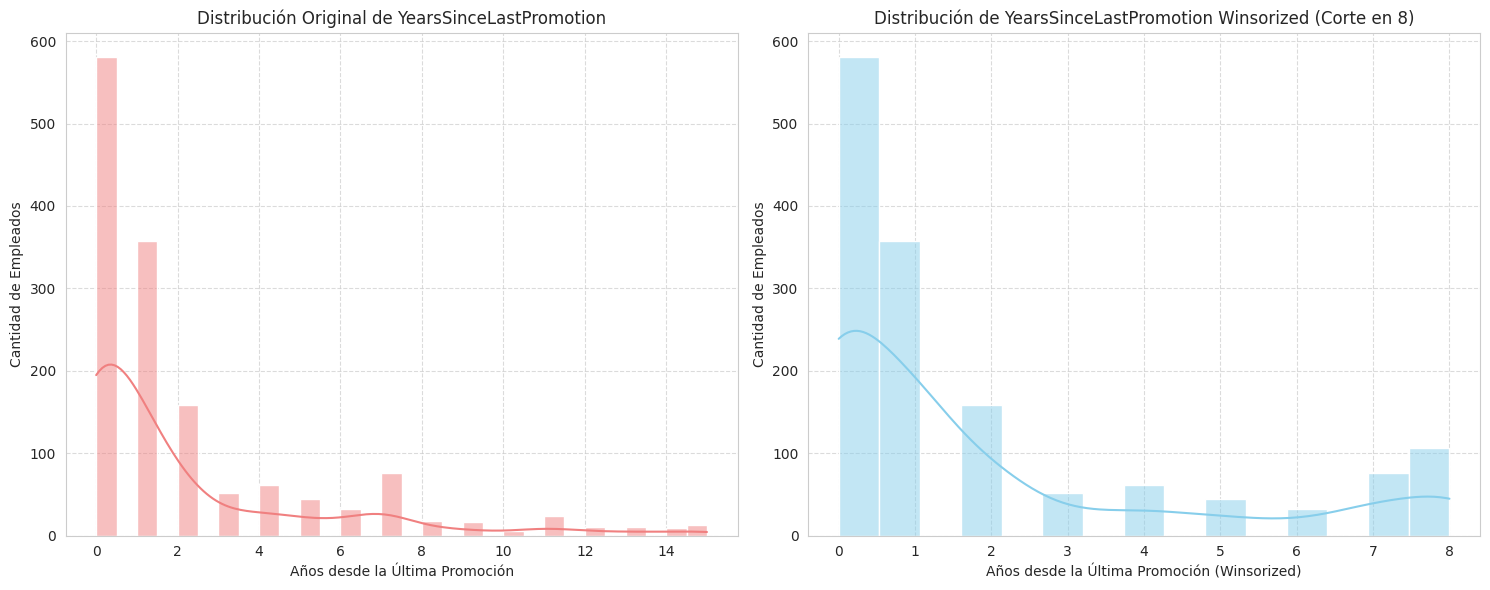

In [ ]:
cutoff_value_years_since_last_promotion = 8
df['YearsSinceLastPromotion_Winsorized_Fixed'] = df['YearsSinceLastPromotion'].clip(upper=cutoff_value_years_since_last_promotion)

print(f"Valor del corte superior para YearsSinceLastPromotion: {cutoff_value_years_since_last_promotion}")

# Verificar los cambios mostrando algunas filas donde se aplicó la winsorización
display(df[['YearsSinceLastPromotion', 'YearsSinceLastPromotion_Winsorized_Fixed']].sort_values(by='YearsSinceLastPromotion', ascending=False).head(10))

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['YearsSinceLastPromotion'], bins=30, kde=True, color='lightcoral')
plt.title('Distribución Original de YearsSinceLastPromotion')
plt.xlabel('Años desde la Última Promoción')
plt.ylabel('Cantidad de Empleados')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
sns.histplot(df['YearsSinceLastPromotion_Winsorized_Fixed'], bins=15, kde=True, color='skyblue')
plt.title('Distribución de YearsSinceLastPromotion Winsorized (Corte en 8)')
plt.xlabel('Años desde la Última Promoción (Winsorized)')
plt.ylabel('Cantidad de Empleados')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
df.drop(columns=['YearsSinceLastPromotion'], inplace=True)

Eliminamos la columna original y dejamos únicamente la trasnformada sin outliers.

- YearsWithCurrManager: 14 outliers

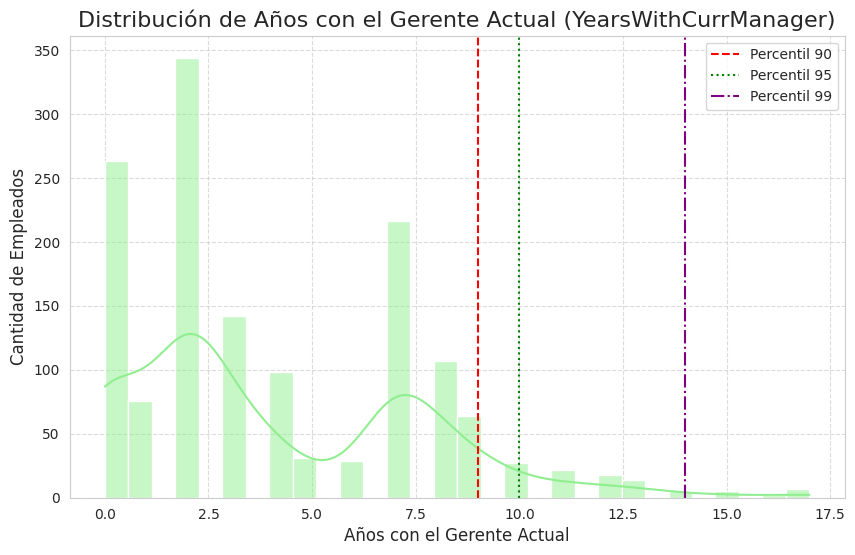

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['YearsWithCurrManager'], bins=30, kde=True, color='lightgreen')
plt.title('Distribución de Años con el Gerente Actual (YearsWithCurrManager)', fontsize=16)
plt.xlabel('Años con el Gerente Actual', fontsize=12)
plt.ylabel('Cantidad de Empleados', fontsize=12)
plt.axvline(df['YearsWithCurrManager'].quantile(0.90), color='red', linestyle='--', label='Percentil 90')
plt.axvline(df['YearsWithCurrManager'].quantile(0.95), color='green', linestyle=':', label='Percentil 95')
plt.axvline(df['YearsWithCurrManager'].quantile(0.99), color='purple', linestyle='-.', label='Percentil 99')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print(df['YearsWithCurrManager'].value_counts().sort_index())

YearsWithCurrManager
0     263
1      76
2     344
3     142
4      98
5      31
6      29
7     216
8     107
9      64
10     27
11     22
12     18
13     14
14      5
15      5
16      2
17      7
Name: count, dtype: int64


Decidimos aplicar la técnica de Windsoring, estableciendo el valor de 10 años con el gerente actual. Tomamos este valor ya que, al ver el conteo de frecuencias, nos pareció un valor lógico para que la frecuencia del límite superior no sea demasiado alta con respecto a las barras anteriores.

Valor del corte superior para YearsWithCurrManager: 10


,YearsWithCurrManager,YearsWithCurrManager_Winsorized_Fixed
1078,17,10
386,17,10
686,17,10
616,17,10
28,17,10
875,17,10
926,17,10
1348,16,10
561,16,10
187,15,10


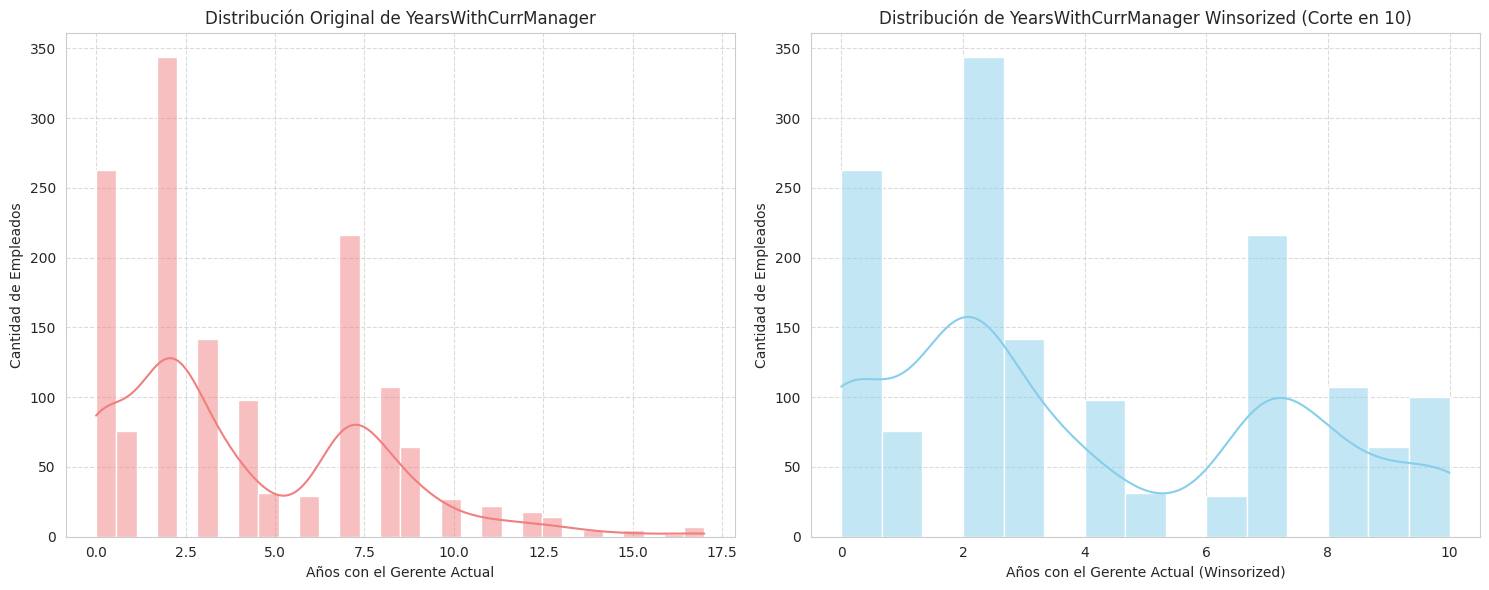

In [ ]:
cutoff_value_years_with_curr_manager = 10
df['YearsWithCurrManager_Winsorized_Fixed'] = df['YearsWithCurrManager'].clip(upper=cutoff_value_years_with_curr_manager)

print(f"Valor del corte superior para YearsWithCurrManager: {cutoff_value_years_with_curr_manager}")

# Verificar los cambios mostrando algunas filas donde se aplicó la winsorización
display(df[['YearsWithCurrManager', 'YearsWithCurrManager_Winsorized_Fixed']].sort_values(by='YearsWithCurrManager', ascending=False).head(10))

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['YearsWithCurrManager'], bins=30, kde=True, color='lightcoral')
plt.title('Distribución Original de YearsWithCurrManager')
plt.xlabel('Años con el Gerente Actual')
plt.ylabel('Cantidad de Empleados')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
sns.histplot(df['YearsWithCurrManager_Winsorized_Fixed'], bins=15, kde=True, color='skyblue')
plt.title('Distribución de YearsWithCurrManager Winsorized (Corte en 10)')
plt.xlabel('Años con el Gerente Actual (Winsorized)')
plt.ylabel('Cantidad de Empleados')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
df.drop(columns=['YearsWithCurrManager'], inplace=True)

Eliminamos la columna original y dejamos únicamente la trasnformada sin outliers.

### **2.3 Análisis de categóricas**

In [ ]:
cols_pos_categoricas = df.select_dtypes(include='object').columns

# Cantidad de valores únicos por variable categórica
print("Cantidad de valores únicos por variable posible categórica:\n")
for col in cols_pos_categoricas:
    n_unicos = df[col].nunique()
    print(f"{col}: {n_unicos} valores únicos")

Cantidad de valores únicos por variable posible categórica:

Attrition: 2 valores únicos
BusinessTravel: 3 valores únicos
Department: 3 valores únicos
EducationField: 6 valores únicos
Gender: 2 valores únicos
JobRole: 9 valores únicos
MaritalStatus: 3 valores únicos
Over18: 1 valores únicos
OverTime: 2 valores únicos


In [ ]:
# Valores únicos por variable categórica

for col in df.select_dtypes(include="object").columns:
  n_unicos = df[col].nunique()
  print(f"\nColumna: {col} (vals unicos: {n_unicos})")
  print(df[col].unique())


Columna: Attrition (vals unicos: 2)
['Yes' 'No']

Columna: BusinessTravel (vals unicos: 3)
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Columna: Department (vals unicos: 3)
['Sales' 'Research & Development' 'Human Resources']

Columna: EducationField (vals unicos: 6)
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

Columna: Gender (vals unicos: 2)
['Female' 'Male']

Columna: JobRole (vals unicos: 9)
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

Columna: MaritalStatus (vals unicos: 3)
['Single' 'Married' 'Divorced']

Columna: Over18 (vals unicos: 1)
['Y']

Columna: OverTime (vals unicos: 2)
['Yes' 'No']


In [ ]:
# Sacamos la columna Over18 porque tiene un solo valor
df.drop(columns=['Over18'], inplace=True)

# Pasamos a columnas binarias las columnas de valores 'Si', 'No'
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

In [ ]:
for col in df.select_dtypes(include="object").columns:
  print(df[col].value_counts())

BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
Gender
Male      882
Female    588
Name: count, dtype: int64
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64
MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64


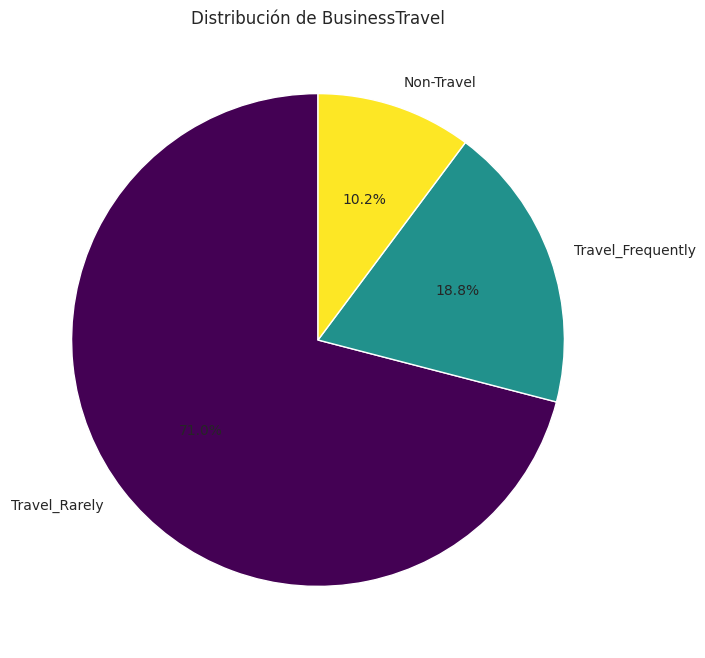

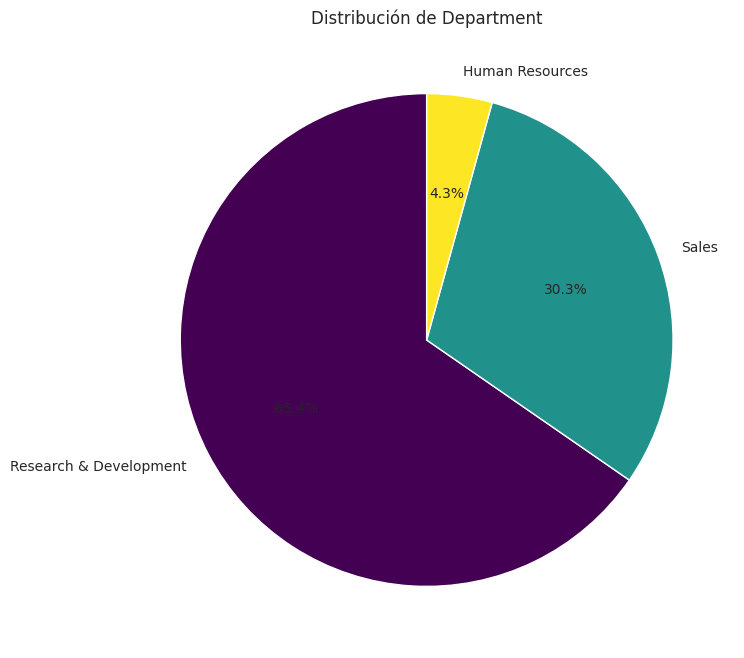

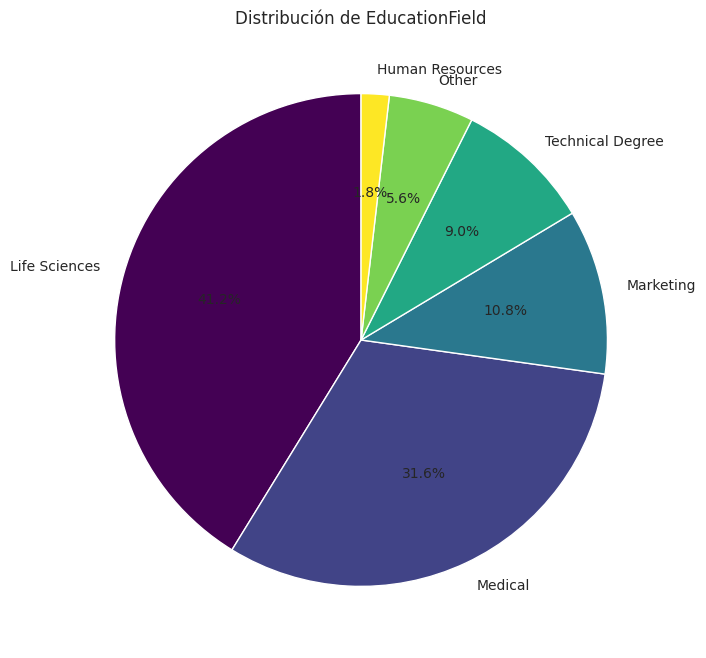

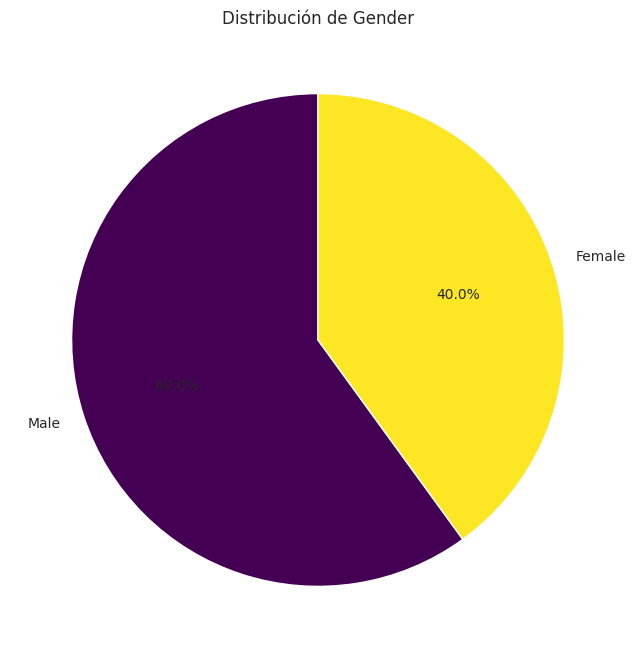

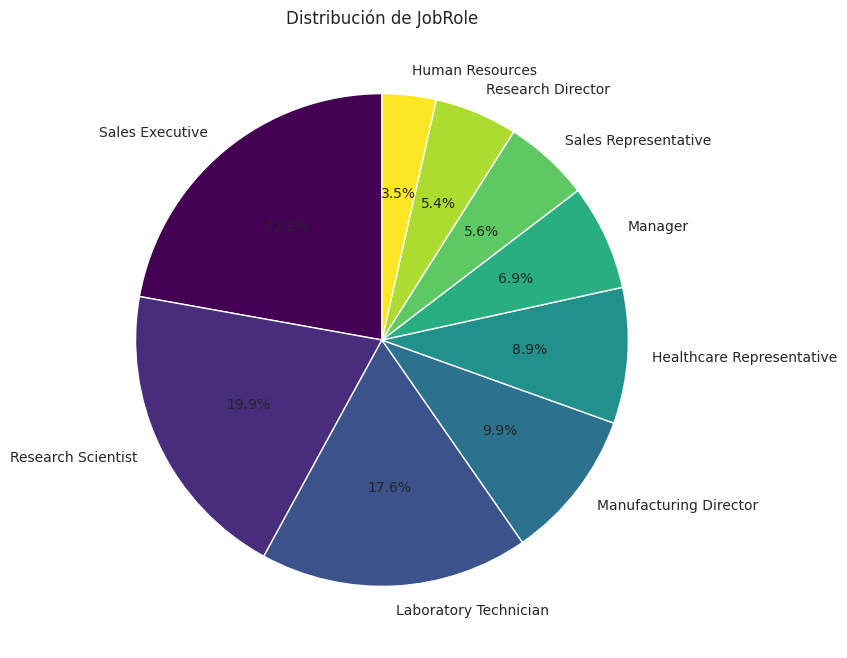

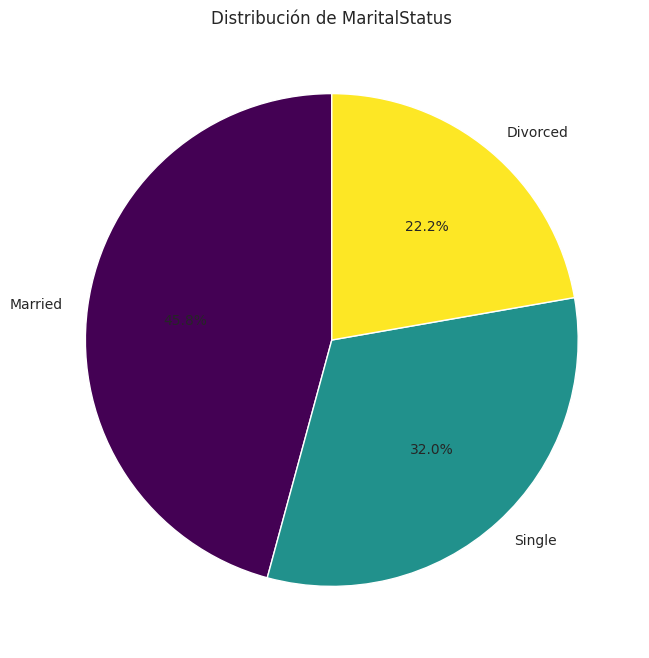

In [ ]:
for col in df.select_dtypes(include="object").columns:
    plt.figure(figsize=(8, 8))
    df[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
    plt.title(f"Distribución de {col}")
    plt.ylabel('') # Ocultar la etiqueta del eje y para una mejor visualización del gráfico de torta
    plt.show()

Buscamos correlaciones lineales entre variables


*   Attrition tiene bastante correlacion lineal, para ser una variable binaria, con Overtime, tambien variable binaria

*   TotalWorkingYears tiene una correlacion de +0.5 con Age, JobLevel y MonthlyIncome, entre otras variables que tienen que ver con la cantidad de años

* La variable Education se relaciona mas con la edad y con la cantidad de empresas en las que se trabajo



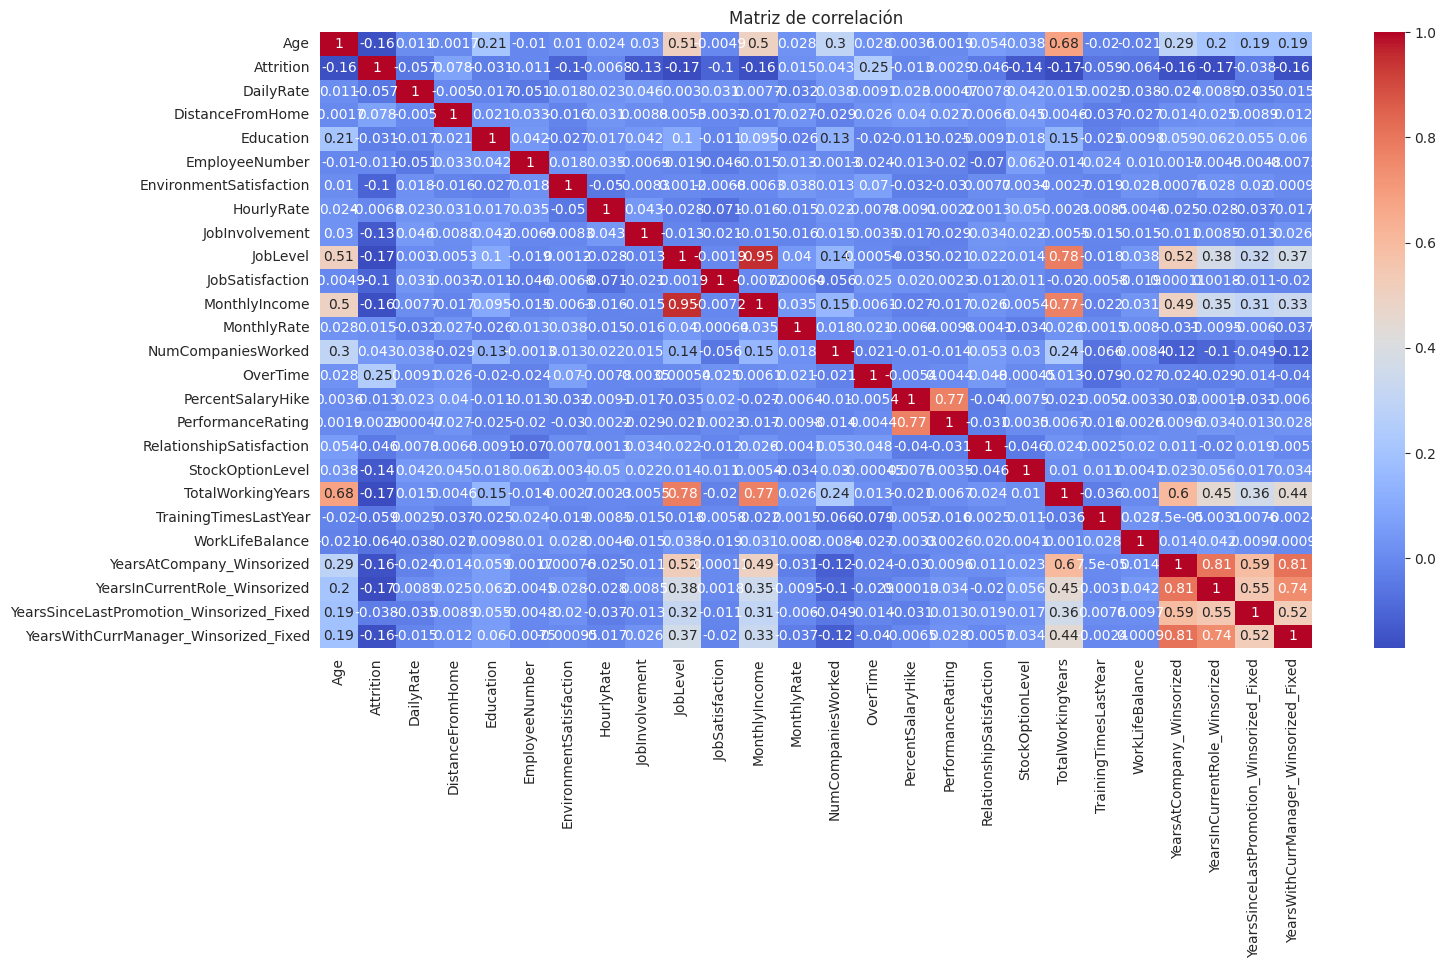

In [ ]:
# Calcular correlaciones
corr = df.corr(numeric_only=True)
# display(corr)

plt.figure(figsize=(16, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

### **2.4 Exploración**

Exploramos distintas opciones.

Media: 2.7208616780045354


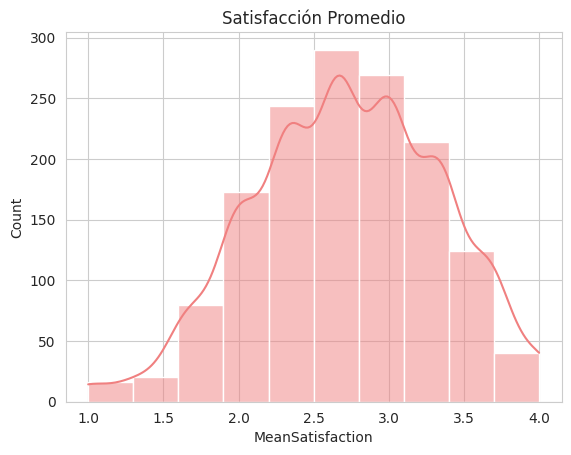

In [ ]:
# Creamos una columna de Satsifaction promedio
columns_satisfaction = [i for i in df.columns if 'satisfaction' in i.lower()]
df['MeanSatisfaction'] = df[columns_satisfaction].sum(axis=1) / 3

sns.histplot(df['MeanSatisfaction'], bins=10, kde=True, color='lightcoral')
plt.title('Satisfacción Promedio')
print('Media:', df['MeanSatisfaction'].mean())
plt.show()

In [ ]:
df[columns_satisfaction + ['MeanSatisfaction']].describe()

,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,MeanSatisfaction
count,1470.000000,1470.000000,1470.000000,1470.000000
mean,2.721769,2.728571,2.712245,2.720862
std,1.093082,1.102846,1.081209,0.628240
min,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.333333
50%,3.000000,3.000000,3.000000,2.666667
75%,4.000000,4.000000,4.000000,3.333333
max,4.000000,4.000000,4.000000,4.000000


En la satisfacción promedio vemos que en general hay satisfacción de los empleados con una media de 2,72 puntos de rating, algo que comparte con el resto de las columnas de satisfacción.

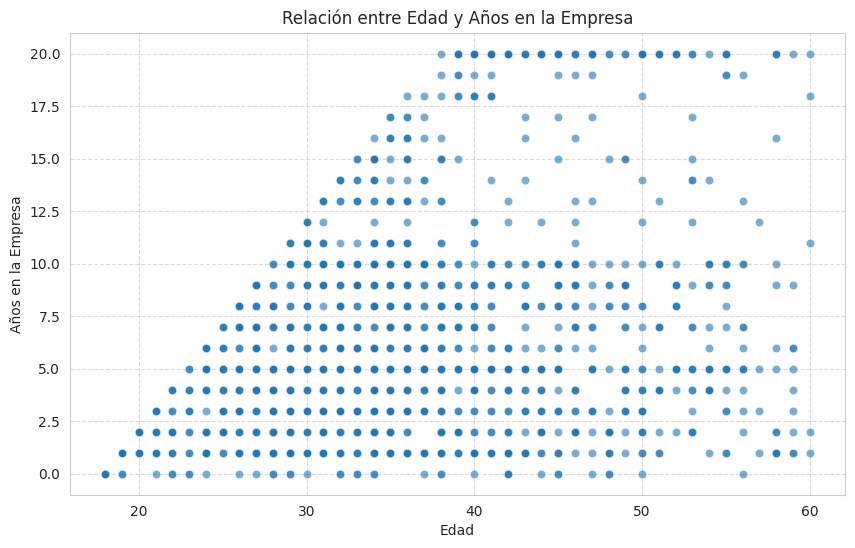

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='YearsAtCompany_Winsorized', alpha=0.6)
plt.title('Relación entre Edad y Años en la Empresa')
plt.xlabel('Edad')
plt.ylabel('Años en la Empresa')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Podemos observar una relación positiva entre la edad y los años en la empresa, aunque hay una alta dispersión. También, la dispersión se extiende hacia una gran cantidad de empleados con edades altas que se quedan pocos años en la empresa.

### **2.5 Análisis de la Variable Objetivo (Attrition)**

Nuestra variable objetivo esta desbalanceada, solo un 16% de los datos, por lo que eso es un desafio de cara a futuro

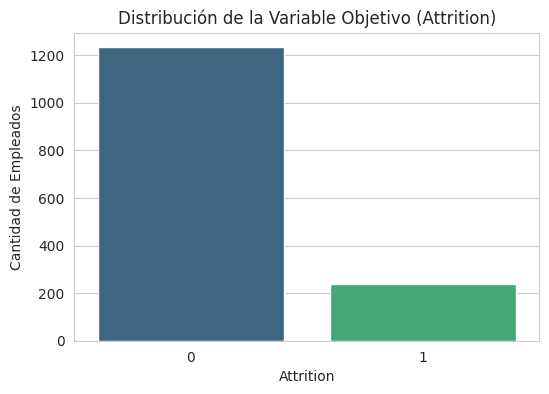

Attrition
0    1233
1     237
Name: count, dtype: int64
Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition', hue='Attrition', palette='viridis', legend=False)
plt.title('Distribución de la Variable Objetivo (Attrition)')
plt.xlabel('Attrition')
plt.ylabel('Cantidad de Empleados')
plt.show()

print(df['Attrition'].value_counts())
print(df['Attrition'].value_counts(normalize=True) * 100)

Comparamos el ingreso mensual según su condición de attrition

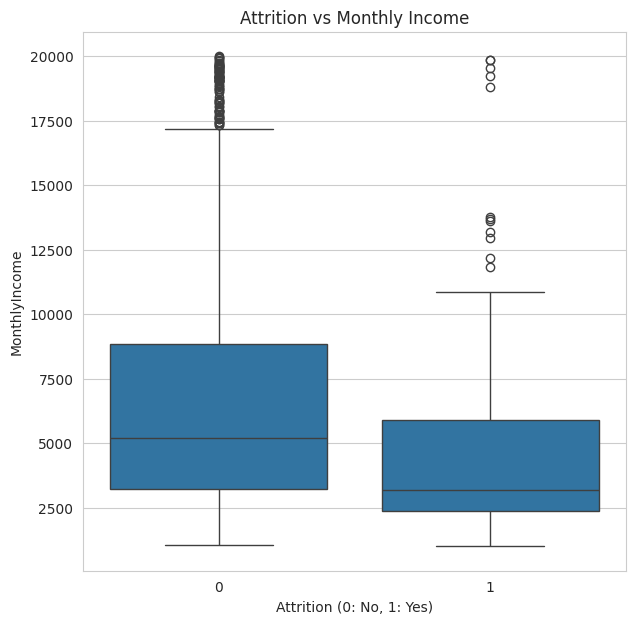

In [ ]:
plt.figure(figsize=(7,7))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')
plt.title('Attrition vs Monthly Income')
plt.xlabel('Attrition (0: No, 1: Yes)')
plt.show()

Los que se van suelen tener un salario más bajo que los que permanecen en sus lugares.

Comparamos la distribucion por Edad

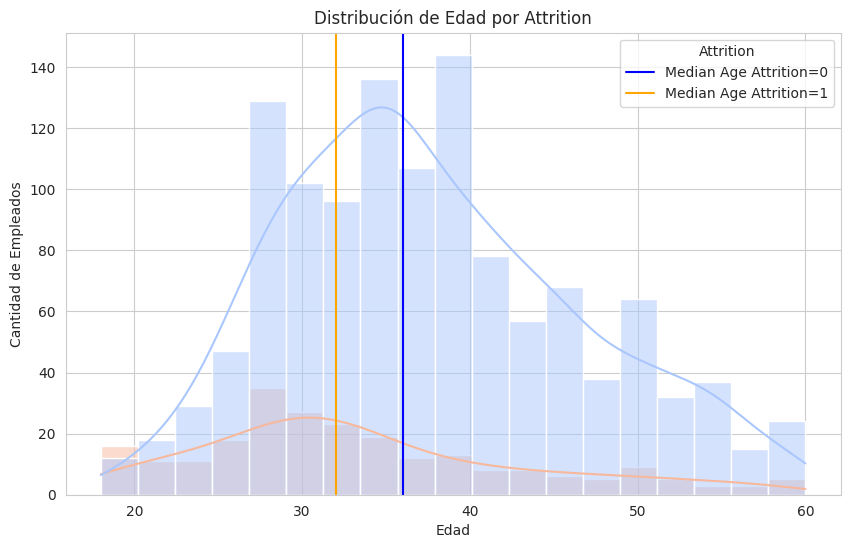

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Attrition', kde=True, palette='coolwarm')
plt.title('Distribución de Edad por Attrition')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Empleados')
# plt.axvline(df[df['Attrition'] == 0]['Age'].mean(), label='Mean Age Attrition=0', color='blue')
plt.axvline(df[df['Attrition'] == 0]['Age'].median(), label='Median Age Attrition=0', color='blue')

# plt.axvline(df[df['Attrition'] == 1]['Age'].mean(), label='Mean Age Attrition=1', color='orange')
plt.axvline(df[df['Attrition'] == 1]['Age'].median(), ymax=40, label='Median Age Attrition=1', color='orange')
plt.legend(title='Attrition')
plt.show()

Podemos observar que los empleados que más abandonan la empresa tienden a ser más jóvenes, por lo que la edad mediana del grupo de attrition es menor que la del grupo sin attrition.

<Axes: xlabel='Age', ylabel='Probability'>

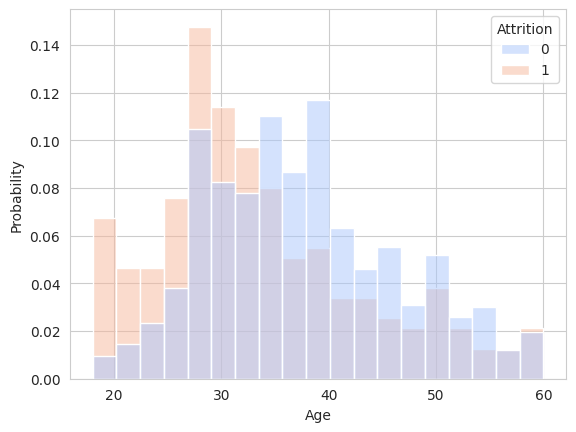

In [ ]:
sns.histplot(data=df, x='Age', hue='Attrition', stat='probability', common_norm=False, palette='coolwarm')

Al analizar la proporción de empleados, podemos confirmar también que los empleados que se abandonan las empresas tienden a concentrarse en edades más bajas, mientras que los que no abandonan se concentran en edades más altas.

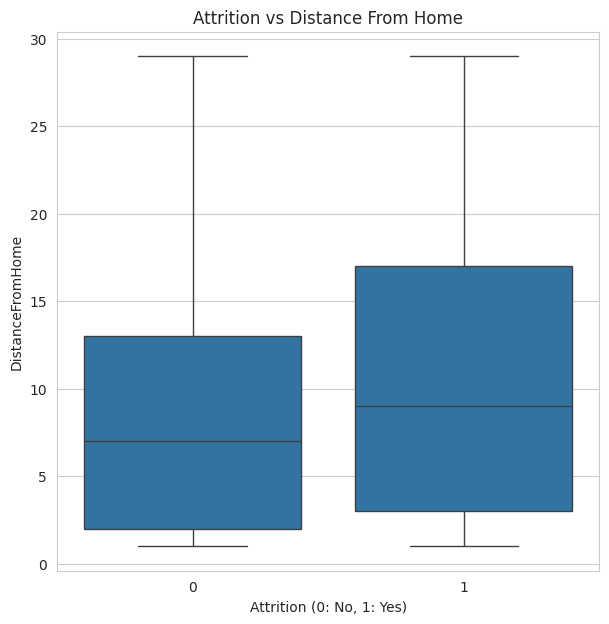

In [ ]:
plt.figure(figsize=(7,7))
sns.boxplot(data=df, x='Attrition', y='DistanceFromHome')
plt.title('Attrition vs Distance From Home')
plt.xlabel('Attrition (0: No, 1: Yes)')
plt.show()

<Axes: xlabel='DistanceFromHome', ylabel='Probability'>

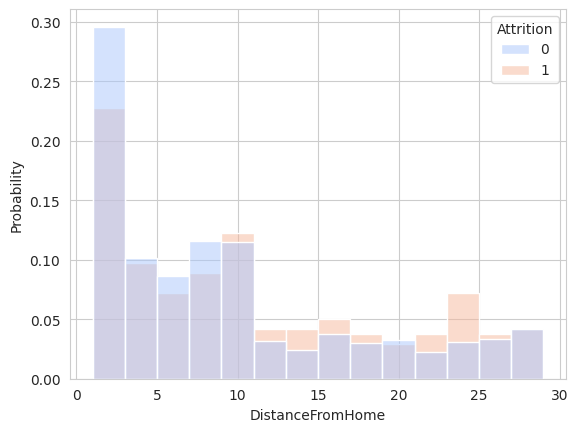

In [ ]:
sns.histplot(data=df, x='DistanceFromHome', hue='Attrition', stat='probability', common_norm=False, palette='coolwarm')

Acá podemos ver que los empleados que hacen attrition tienden a estar a una distancia más lejos de su casa que los que no hacen attrition.

<Axes: xlabel='YearsSinceLastPromotion_Winsorized_Fixed', ylabel='Probability'>

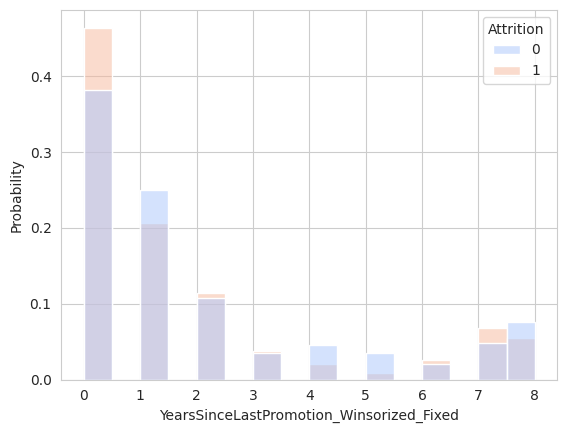

In [ ]:
sns.histplot(data=df, x='YearsSinceLastPromotion_Winsorized_Fixed', hue='Attrition', stat='probability', common_norm=False, palette='coolwarm')

En este gráfico observamos que una gran proporción de los empleados que recientemente fueron promocionados tienden a irse del trabajo. Esta no es una tendencia esperada, ya que pensaríamos que si un empleado fue ascendido, no tendería a irse de su trabajo.

<Axes: xlabel='YearsWithCurrManager_Winsorized_Fixed', ylabel='Probability'>

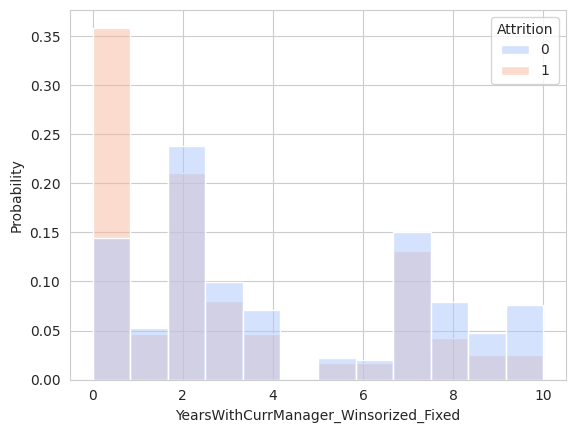

In [ ]:
sns.histplot(data=df, x='YearsWithCurrManager_Winsorized_Fixed', hue='Attrition', stat='probability', common_norm=False, palette='coolwarm')

En este gráfico podemos ver que los empleados que hacen attrition tienden a estar hace muy pocos años con su actual manager, sugiriendo que podría haber, por ejemplo, algún tipo de malestar con el actual y reciente manager.

<Axes: xlabel='TotalWorkingYears', ylabel='Probability'>

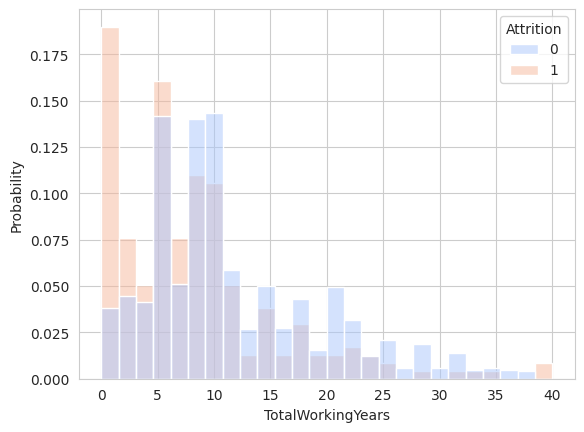

In [ ]:
sns.histplot(data=df, x='TotalWorkingYears', hue='Attrition', stat='probability', common_norm=False, palette='coolwarm')

En este gráfico podemos observar que los empleados que se van de sus empresas tienden a tener menos años totales de trabajo que los que se quedan.

<Axes: xlabel='YearsInCurrentRole_Winsorized', ylabel='Probability'>

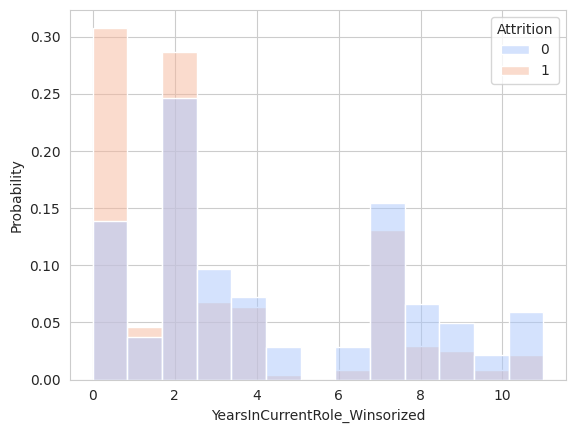

In [ ]:
sns.histplot(data=df, x='YearsInCurrentRole_Winsorized', hue='Attrition', stat='probability', common_norm=False, palette='coolwarm')

Acá podemos observar que los empleados que hacen attrition están hace menos años en su rol actual que los que permanecen en sus empresas.

Hacemos otras comparaciones entre las personas que se fueron y las que no

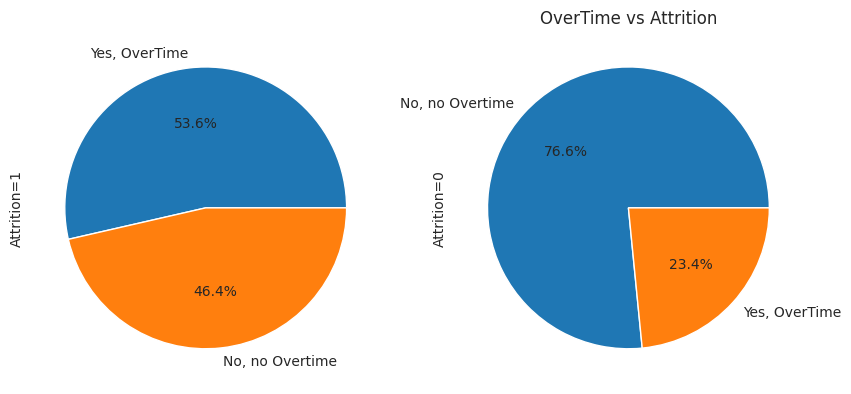

In [ ]:
df_attrition_yes = df[df['Attrition'] == 1]
df_attrition_no = df[df['Attrition'] == 0]

fig, axes = plt.subplots(1,2,figsize=(10,5))
df_attrition_yes['OverTime'].map({1:'Yes, OverTime',0:'No, no Overtime'}).value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0], label='Attrition=1')
df_attrition_no['OverTime'].map({1:'Yes, OverTime',0:'No, no Overtime'}).value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1], label='Attrition=0')

plt.title('OverTime vs Attrition')
plt.show()

Acá podemos observar que:
- Del total de las personas que se van de sus empresas, la mayor parte trabajó horas extra.
- Del total de las personas que no se van de sus empresas, la mayor parte no trabajó horas extra.

In [ ]:
print('Crosstab de Attrition por OverTime (Normalizado por fila):')
display(pd.crosstab(df['OverTime'].map({1:'Yes',0:'No'}), df['Attrition'].map({1:'Yes',0:'No'}), normalize='index'))

Crosstab de Attrition por OverTime (Normalizado por fila):


Attrition,No,Yes
OverTime,,
No,0.895636,0.104364
Yes,0.694712,0.305288


Podemos observar que el porcentaje de personas que se van de sus empresas es mucho más alto cuando hacen horas extras que cuando no las hacen.

In [ ]:
pd.crosstab(df['MaritalStatus'], df['Attrition'], normalize='index')

Attrition,0,1
MaritalStatus,,
Divorced,0.899083,0.100917
Married,0.875186,0.124814
Single,0.744681,0.255319


Podemos ver que los empleados presentan una probabilidad de attrition mayor en solteros que en casados o divorciados.

In [ ]:
pd.crosstab(df['JobRole'], df['Attrition'], normalize='index')

Attrition,0,1
JobRole,,
Healthcare Representative,0.931298,0.068702
Human Resources,0.769231,0.230769
Laboratory Technician,0.760618,0.239382
Manager,0.950980,0.049020
Manufacturing Director,0.931034,0.068966
Research Director,0.975000,0.025000
Research Scientist,0.839041,0.160959
Sales Executive,0.825153,0.174847
Sales Representative,0.602410,0.397590


Los roles más jerárquicos presentan menor probabilidad de attrition que los roles en estratos más bajos de las compañías.

In [ ]:
pd.crosstab(df['Gender'], df['Attrition'], normalize='index')

Attrition,0,1
Gender,,
Female,0.852041,0.147959
Male,0.829932,0.170068


No destacamos un patrón de género entre las personas que se fueron o se quedaron en sus empresas.

In [ ]:
pd.crosstab(df['Department'], df['Attrition'], normalize='index')

Attrition,0,1
Department,,
Human Resources,0.809524,0.190476
Research & Development,0.861602,0.138398
Sales,0.793722,0.206278


<Axes: xlabel='BusinessTravel'>

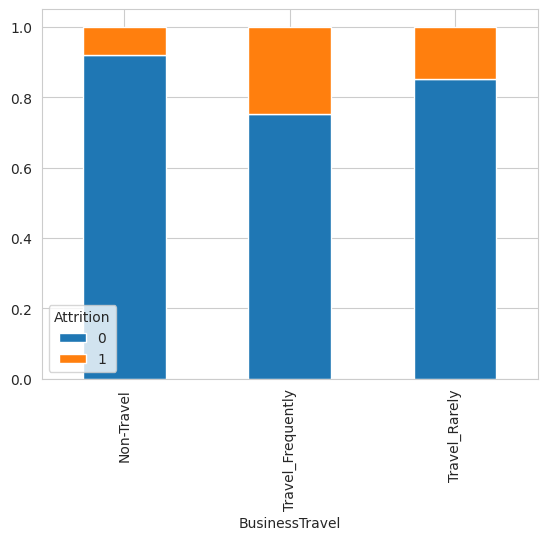

In [ ]:
pd.crosstab(df['BusinessTravel'], df['Attrition'], normalize='index').plot(kind='bar', stacked=True)

La proporción de empleados que realizan attrition es mayor en aquellos que viajan frecuentemente que en aquellos que no viajan o que lo hacen raramente.

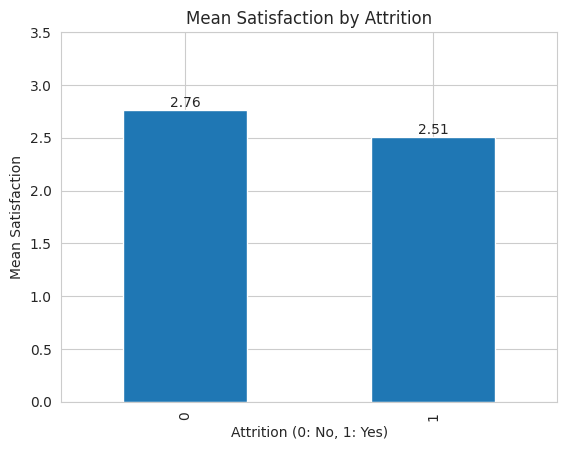

In [ ]:
ax = df.groupby('Attrition')['MeanSatisfaction'].mean().plot(kind='bar')
plt.title('Mean Satisfaction by Attrition')
plt.ylabel('Mean Satisfaction')
plt.xlabel('Attrition (0: No, 1: Yes)')
plt.ylim(0,3.5)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

El promedio de satisfacción de las personas que se van del trabajo es menor a las que permanecen.

## Guardamos DataFrame con cambios

In [ ]:
df.to_csv('HR-EmployeeAttrition_Clean.csv', index=False)

In [ ]:
from google.colab import files

files.download('HR-EmployeeAttrition_Clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>